# Caregiver Attitude Profiles Toward Early Infant Autism Screening

### A descriptive cluster analysis of parent/caregiver survey responses

---

## Study context

These data come from a parent/caregiver survey about **hypothetical early autism screening in infancy**. Respondents were asked
how they would feel about being offered a free autism screening test for a 4-month-old baby, and were then asked about the
usefulness and accuracy of such a test, their emotional reaction to it, its ethical and moral acceptability, how willing they
would be to screen and when, what they would gain or lose from a result, how much they would trust a result, how feasible the
procedures would be, and how they would respond behaviourally.

## What this analysis does

It groups caregivers into a small number of **attitude profiles** based only on how they answered the screening-attitude items,
then describes how those profiles differ in willingness, context and background.

| # | Question | Answered in |
| --- | --- | --- |
| 1 | Are there distinct groups of caregivers with different levels of support, trust, concern and ethical acceptance? | §7-§9 |
| 2 | How do the groups differ in willingness to screen **now** versus **later** versus **not at all**? | §10 |
| 3 | How do the groups differ by autism experience, autism knowledge, healthcare access, child/family characteristics and demographics? | §11 |
| 4 | What does this imply for communication, informed consent, implementation and family support? | Key Findings |

## Scope and limits, stated up front

This analysis is **descriptive and exploratory**. The clusters are patterns of response *within this sample*. They are **not**
causal, **not** diagnostic, **not** stable caregiver "types", and **not** clinically validated categories. Cluster labels are
shorthand for an observed response pattern, nothing more. No individual should be assigned to a profile for any clinical or
programmatic purpose on the basis of this work.

## Data files and the role each one plays

| File | Role |
| --- | --- |
| **`cleaned_autism_study_data.csv`** | **Primary analysis dataset.** All clustering and profiling is done on these records. |
| `InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv` | Verification only: the numeric REDCap codes, used to confirm response ordering and recover original field names. |
| `InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv` | Verification only: supplies the code ↔ label dictionary. |
| `Analysis questions - Sheet3.csv` | Reference only: the study team's analysis plan, used to confirm construct definitions. |

The cleaned file stores **response text** ("Very ethically right"), not numbers, and its column headers are full question strings.
§1 therefore decodes it to numeric using the label dictionary recovered from the other two files, renames the columns to their
original REDCap field names, and then **verifies the decoded result against the raw numeric export** before anything else runs.

## Roadmap

| § | Stage |
| --- | --- |
| 1 | Load, decode and verify the primary dataset |
| 2 | Inspect the data: types, ranges, missingness |
| 3 | Choose candidate clustering variables from five attitude domains |
| 4 | Align response directions and log every reverse-coding |
| 5 | Screen out unusable items; report every exclusion |
| 6 | Correlations, domain scores, Cronbach's alpha |
| 7 | Choose the number of clusters (k = 2 … 5) |
| 8 | Fit K-means; check robustness with Ward linkage |
| 9 | Name and profile the clusters |
| 10 | Willingness to screen now / later / not at all |
| 11 | Post-cluster comparisons: context and demographics |
| — | **Key Findings and Interpretation** |

---
# §1. Load, decode and verify the primary dataset

The cleaned file is the analysis dataset. Three things have to happen before it is usable:

1. **Rename its columns** from full question text to the original REDCap field names, so the code is readable.
2. **Decode its text responses to numbers**, using the code ↔ label dictionary recovered from the raw and labeled exports.
3. **Verify the result**, by checking the decoded values against the raw numeric export record by record.

Step 3 is not optional. The raw export has 183 columns and the labeled export has 186, and they do **not** line up
position-for-position — from the demographics block onward the offset grows to +1 and then +3. Pairing them by position would
silently mislabel every demographic variable. Instead we pair them by **content**: a raw column and a labeled column describe the
same item only if their observed values form a one-to-one correspondence in both directions and they share a missingness pattern.

In [1]:
# --- 1.1 Setup ----------------------------------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 190)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# Okabe-Ito: a colourblind-safe qualitative palette (deuteranopia / protanopia / tritanopia safe).
OKABE_ITO = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#F0E442', '#000000']
GREY = '#6E6E6E'
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 300, 'figure.facecolor': 'white',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5, 'legend.fontsize': 9.5,
})

FILES = {
    'clean':   'cleaned_autism_study_data.csv',
    'raw':     'InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv',
    'labels':  'InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv',
    'plan':    'Analysis questions - Sheet3.csv',
    'plan_alt': 'Analysis-questions-Sheet3.csv',
}


def find_file(filename: str):
    here = Path.cwd()
    for directory in [here, here / 'Caregiver Project', *list(here.parents)[:3], Path.home() / 'Downloads']:
        for candidate in (directory / filename, directory / 'Caregiver Project' / filename):
            if candidate.exists():
                return candidate
    return None


paths = {key: find_file(name) for key, name in FILES.items()}
for key in ('clean', 'raw', 'labels'):
    if paths[key] is None:
        raise FileNotFoundError(f'Required file not found: {FILES[key]}')

clean_labeled = pd.read_csv(paths['clean'], low_memory=False)     # PRIMARY (text responses)
raw_numeric = pd.read_csv(paths['raw'], low_memory=False)         # verification only
labels_text = pd.read_csv(paths['labels'], low_memory=False)      # verification only

OUT_DIR = paths['clean'].resolve().parent / 'Caregiver Outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem: str):
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{stem}.{suffix}', bbox_inches='tight', facecolor='white')


def caption(text: str):
    display(Markdown(f'> **How to read this figure.** {text}'))


display(Markdown('### Files loaded'))
display(pd.DataFrame({
    'role': ['PRIMARY analysis dataset', 'verification: numeric codes', 'verification: value labels',
             'reference: analysis plan'],
    'file': [FILES['clean'], FILES['raw'], FILES['labels'],
             FILES['plan'] if paths['plan'] else (FILES['plan_alt'] if paths['plan_alt'] else 'not found')],
    'rows': [len(clean_labeled), len(raw_numeric), len(labels_text),
             len(pd.read_csv(paths['plan'] or paths['plan_alt'], header=None)) if (paths['plan'] or paths['plan_alt']) else 0],
    'columns': [clean_labeled.shape[1], raw_numeric.shape[1], labels_text.shape[1], '-'],
}))
print(f'Outputs will be written to: {OUT_DIR}')

### Files loaded

,role,file,rows,columns
0,PRIMARY analysis dataset,cleaned_autism_study_data.csv,135,186
1,verification: numeric codes,InfantAutismScreenin-FullDataset_DATA_2026-01-...,177,183
2,verification: value labels,InfantAutismScreenin-FullDataset_DATA_LABELS_2...,177,186
3,reference: analysis plan,Analysis questions - Sheet3.csv,44,-


Outputs will be written to: /Users/namomac/esd-redcap-metadata-watcher/Caregiver Project/Caregiver Outputs


In [2]:
# --- 1.2 Recover the code <-> label dictionary and decode the cleaned file -----------------------
def is_same_item(codes: pd.Series, labs: pd.Series, min_overlap: int = 5) -> bool:
    '''True when numeric codes and text labels are in one-to-one correspondence (both directions).'''
    both = codes.notna() & labs.notna()
    if both.sum() < min_overlap:
        return False
    pair = pd.DataFrame({'c': codes[both].astype(str), 'l': labs[both].astype(str)})
    if pair.groupby('c')['l'].nunique().max() != 1 or pair.groupby('l')['c'].nunique().max() != 1:
        return False
    return (codes.isna().to_numpy() == labs.isna().to_numpy()).mean() > 0.97


offset, alignment = 0, []
for i in range(raw_numeric.shape[1]):
    matched = -1
    for shift in range(offset, min(offset + 6, labels_text.shape[1] - i)):
        if is_same_item(raw_numeric.iloc[:, i], labels_text.iloc[:, i + shift]):
            offset, matched = shift, i + shift
            break
    alignment.append({'field': raw_numeric.columns[i], 'raw_idx': i, 'lab_idx': matched})
alignment = pd.DataFrame(alignment)
matched_rows = alignment[alignment['lab_idx'] >= 0]

# question text, code -> label, and label -> code, keyed by REDCap field name
question_text, code_to_label, label_to_code, header_to_field = {}, {}, {}, {}
for row in matched_rows.itertuples():
    header = str(labels_text.columns[int(row.lab_idx)])
    header_to_field.setdefault(header, row.field)
    if not header.startswith('Unnamed'):
        question_text[row.field] = ' '.join(header.replace('\n', ' ').split())
    codes, labs = raw_numeric.iloc[:, row.raw_idx], labels_text.iloc[:, int(row.lab_idx)]
    both = codes.notna() & labs.notna()
    if both.sum() and pd.api.types.is_numeric_dtype(codes):
        mapping = dict(zip(labs[both].astype(str), codes[both]))
        if 1 < len(mapping) <= 30:
            label_to_code[row.field] = mapping
            code_to_label[row.field] = {v: k for k, v in mapping.items()}

# Rename the cleaned file's headers to REDCap field names (positionally unique headers only).
clean = clean_labeled.copy()
rename_map, used = {}, set()
for j, header in enumerate(clean.columns):
    field = header_to_field.get(str(header))
    if field and field not in used:
        rename_map[header] = field
        used.add(field)
clean = clean.rename(columns=rename_map)
clean = clean.rename(columns={clean.columns[0]: 'record_id'})

# Decode text responses to numeric codes.
decoded = clean.copy()
for field, mapping in label_to_code.items():
    if field in decoded.columns and decoded[field].dtype == object:
        decoded[field] = decoded[field].astype(str).map(mapping)
for field in decoded.columns:
    if decoded[field].dtype == object:
        numeric_try = pd.to_numeric(decoded[field], errors='coerce')
        if numeric_try.notna().sum() >= decoded[field].notna().sum():
            decoded[field] = numeric_try

# --- VERIFICATION: does the decoded cleaned file agree with the raw numeric export? --------------
decoded['record_id'] = pd.to_numeric(decoded['record_id'], errors='coerce').astype('Int64')
raw_indexed = raw_numeric.set_index('record_id')
check_fields = [f for f in decoded.columns
                if f in raw_indexed.columns and pd.api.types.is_numeric_dtype(decoded[f])
                and f != 'record_id']
verify_rows = []
record_ids = decoded['record_id'].astype('int64').to_numpy()
for field in check_fields:
    left = pd.to_numeric(decoded[field], errors='coerce').to_numpy(dtype=float)
    right = pd.to_numeric(raw_indexed[field].reindex(record_ids), errors='coerce').to_numpy(dtype=float)
    comparable = ~np.isnan(left) & ~np.isnan(right)
    if comparable.sum() == 0:
        continue
    verify_rows.append({'field': field, 'compared': int(comparable.sum()),
                        'agree': int((left[comparable] == right[comparable]).sum())})
verify = pd.DataFrame(verify_rows)
verify['pct_agree'] = verify['agree'] / verify['compared'] * 100
mismatched = verify[verify['pct_agree'] < 100]

display(Markdown('### 1.2 Decoding verification'))
display(pd.DataFrame({
    'check': ['Columns paired between the raw and labeled exports',
              'Fields with a recovered value dictionary',
              'Cleaned columns renamed to REDCap field names',
              'Numeric fields cross-checked against the raw export',
              'Fields agreeing with the raw export on 100% of records'],
    'result': [len(matched_rows), len(label_to_code), len(rename_map), len(verify),
               f'{len(verify) - len(mismatched)} of {len(verify)}'],
}))
assert mismatched.empty, f'Decoding mismatch in: {mismatched["field"].tolist()[:10]}'
print('PASS - every decoded field reproduces the raw numeric export exactly.')

display(Markdown(
    'Column pairing by position would have failed. Three demographic fields, for illustration:'
))
demo_check = alignment[alignment['field'].isin(['demo_country', 'demo_cg1education', 'demo_hcare_access'])]
display(pd.DataFrame({
    'field': demo_check['field'].values,
    'position offset': (demo_check['lab_idx'] - demo_check['raw_idx']).values,
    'label if paired by position (wrong)': [str(labels_text.columns[int(i)])[:44] for i in demo_check['raw_idx']],
    'label after content pairing (correct)': [str(labels_text.columns[int(j)])[:44] for j in demo_check['lab_idx']],
}))

### 1.2 Decoding verification

,check,result
0,Columns paired between the raw and labeled exp...,152
1,Fields with a recovered value dictionary,99
2,Cleaned columns renamed to REDCap field names,152
3,Numeric fields cross-checked against the raw e...,110
4,Fields agreeing with the raw export on 100% of...,110 of 110


PASS - every decoded field reproduces the raw numeric export exactly.


Column pairing by position would have failed. Three demographic fields, for illustration:

,field,position offset,label if paired by position (wrong),label after content pairing (correct)
0,demo_country,1,What year was your first child born?,Do you live in the US?
1,demo_cg1education,1,Gender,YOUR highest level of education
2,demo_hcare_access,1,Describe the area where you live,"How easy is it for you to get healthcare, li"


---
# §2. Inspecting the primary dataset

Before choosing any variable we look at what is actually in the file: how many records, what each column contains, how much is
missing, and how much variation each item has. Items where almost everyone gave the same answer cannot separate anyone into
groups, so they are identified here and formally excluded in §5.

In [3]:
# --- 2. Overview of the cleaned dataset ---------------------------------------------------------
analysis_df = decoded.copy()

overview = pd.DataFrame({
    'quantity': ['Records in the cleaned file', 'Columns in the cleaned file',
                 'Columns successfully renamed to REDCap fields', 'Columns with a value dictionary',
                 'Columns that are entirely missing'],
    'value': [len(analysis_df), analysis_df.shape[1], len(rename_map),
              sum(1 for f in analysis_df.columns if f in code_to_label),
              int(analysis_df.isna().all().sum())],
})
display(Markdown('### 2.1 Dataset overview'))
display(overview)

# Survey-completion status - the basis for the analytic sample in §5.
completion = pd.DataFrame({
    'instrument': ['Family Information Form', 'Thinking About Autism (attitudes)', 'Demographics'],
    'field': ['family_information_form_complete', 'tfa_complete', 'demographics_complete'],
})
completion['complete (n)'] = [int((analysis_df[f] == 2).sum()) for f in completion['field']]
completion['incomplete (n)'] = [int((analysis_df[f] != 2).sum()) for f in completion['field']]
display(Markdown('### 2.2 Survey completion status'))
display(completion)

# Missingness across the attitude block, which is where the clustering variables live.
attitude_block = [c for c in analysis_df.columns if str(c).startswith('tfa_')]
missing_profile = (analysis_df[attitude_block].isna().mean() * 100).sort_values(ascending=False)
display(Markdown('### 2.3 Missingness across the attitude items (worst 12)'))
display(missing_profile.head(12).round(1).rename('% missing').to_frame())
print(f'{int((missing_profile <= 10).sum())} of {len(attitude_block)} attitude columns have 10% or less missing data.')

### 2.1 Dataset overview

,quantity,value
0,Records in the cleaned file,135
1,Columns in the cleaned file,186
2,Columns successfully renamed to REDCap fields,152
3,Columns with a value dictionary,99
4,Columns that are entirely missing,25


### 2.2 Survey completion status

,instrument,field,complete (n),incomplete (n)
0,Family Information Form,family_information_form_complete,135,0
1,Thinking About Autism (attitudes),tfa_complete,131,4
2,Demographics,demographics_complete,131,4


### 2.3 Missingness across the attitude items (worst 12)

,% missing
tfa_feedback_other,81.50
tfa_whylater,68.10
tfa_test_future,67.40
tfa_comments_gained_lost,67.40
tfa_comments_gain_loss,56.30
tfa_comments_regrets_pos,49.60
tfa_comments_test,43.70
tfa_comments_regrets,34.80
tfa_no_gains_neg,10.40
tfa_comfortable,5.90


65 of 74 attitude columns have 10% or less missing data.


---
# §3. Candidate clustering variables

Clustering inputs are restricted to items that measure **an attitude toward early infant autism screening**. Everything else -
demographics, family background, free text, record identifiers, timestamps, survey-completion flags - is held back for §11, where
it is used to *describe* the clusters after they exist.

Candidates are drawn from the five conceptual domains below.

| Domain | What it captures | Candidate items |
| --- | --- | --- |
| **A. Perceived benefit and usefulness** | Value of early intervention, value of a screening result | `tfa_intervene`, `tfa_wchild`, `tfa_track`, `tfa_overall_help` |
| **B. Screening confidence and acceptability** | Minimum acceptable accuracy, confidence in a result, willingness and timing | `tfa_screen_accuracy`, `tfa_future`, `tfa_believe_positive`, `tfa_believe_negative`, `tfa_free_screen`, `tfa_test_choice`, `tfa_test_today`, `tfa_test_future` |
| **C. Ethical and moral attitudes** | Whether infant screening is ethically and morally right | `tfa_scan_any`, `tfa_scan_mine` |
| **D. Emotional concern and anticipated burden** | Emotional reaction, anticipated gain/loss and regret after a result | `tfa_happy`, `tfa_trusting`, `tfa_comfortable`, `tfa_scared`, `tfa_sad`, `tfa_angry`, `tfa_disgusted`, `tfa_surprised`, `tfa_gain_vs_loss`, `tfa_gain_vs_loss_neg`, `tfa_regret`, `tfa_regret_pos` |
| **E. Practical feasibility and test modality** | How difficult/doable participation is; which procedures are acceptable | `tfa_difficult`, `tfa_doable`, `tfa_separate_*`, `tfa_series_*`, `tfa_mri`, `tfa_eeg`, `tfa_blood`, `tfa_video`, `tfa_saliva`, `tfa_heart`, `tfa_observe` |

Two deliberate exclusions from the clustering inputs, both revisited in §11:

- **`tfa_interact_positive` / `tfa_interact_negative`** ("would the result change how you interact with your baby?") describe an
  anticipated *behavioural consequence* of a result rather than an attitude toward screening.
- **`tfa_test_future`** (chosen age, if deferring) was shown only to caregivers who chose to defer, so it is missing for
  two-thirds of the sample by design.

The data dictionary below is built from the file itself, so it reflects what is actually present rather than what is expected.

In [4]:
# --- 3. Data dictionary for the candidate clustering variables ----------------------------------
CANDIDATES = {
    'A. Perceived benefit / usefulness': {
        'tfa_intervene': 'Importance of early intervention (early help and support)',
        'tfa_wchild': 'Importance of well-child checkups',
        'tfa_track': 'Helpfulness of tracking infant growth and development',
        'tfa_overall_help': 'Value of a result that gives autism status only, not support needs',
    },
    'B. Screening confidence / acceptability': {
        'tfa_screen_accuracy': 'Minimum accuracy the test would need to have',
        'tfa_future': 'Certainty the test would need about how much help the child will need',
        'tfa_believe_positive': 'How much they would believe an "is autistic" result',
        'tfa_believe_negative': 'How much they would believe a "not autistic" result',
        'tfa_free_screen': 'Would you do a free autism screening test for YOUR 4-month-old?',
        'tfa_test_choice': 'Should doctors screen 4-month-olds? (policy view)',
        'tfa_test_today': 'Would you do it now, earlier, later, or not at all?',
    },
    'C. Ethical / moral attitudes': {
        'tfa_scan_any': 'Is it ethical for paediatricians to offer infant screening to all babies?',
        'tfa_scan_mine': 'Is it morally right to have a 4-month-old screened for autism?',
    },
    'D. Emotional concern / anticipated burden': {
        'tfa_happy': 'Emotional reaction: happy', 'tfa_trusting': 'Emotional reaction: trusting (confident in doctor)',
        'tfa_comfortable': 'Emotional reaction: comfortable', 'tfa_scared': 'Emotional reaction: scared',
        'tfa_sad': 'Emotional reaction: sad', 'tfa_angry': 'Emotional reaction: angry',
        'tfa_disgusted': 'Emotional reaction: disgusted', 'tfa_surprised': 'Emotional reaction: surprised',
        'tfa_gain_vs_loss': 'After an "is autistic" result: gained more or lost more?',
        'tfa_gain_vs_loss_neg': 'After a "not autistic" result: gained more or lost more?',
        'tfa_regret': 'Regret about testing, after an "is autistic" result',
        'tfa_regret_pos': 'Regret about testing, after a "not autistic" result',
    },
    'E. Practical feasibility / test modality': {
        'tfa_difficult': 'Difficulty of adding 15-30 minutes to the existing visit',
        'tfa_doable': 'Doability of adding 15-30 minutes to the existing visit',
        'tfa_separate_difficult': 'Difficulty of ONE separate specialist appointment',
        'tfa_separate_doable': 'Doability of ONE separate specialist appointment',
        'tfa_series_difficult': 'Difficulty of a SERIES of specialist appointments',
        'tfa_series_doable': 'Doability of a SERIES of specialist appointments',
        'tfa_mri': 'Acceptability: MRI while baby naps (2-3 hours)',
        'tfa_eeg': 'Acceptability: EEG while baby is awake (1 hour)',
        'tfa_blood': 'Acceptability: blood test (10-15 min)',
        'tfa_video': 'Acceptability: watching movies while observed (15-30 min)',
        'tfa_saliva': 'Acceptability: saliva test (5-10 min)',
        'tfa_heart': 'Acceptability: heart-rate test (10-15 min)',
        'tfa_observe': 'Acceptability: doctor observation of behaviour (30-60 min)',
    },
}
CANDIDATE_FIELDS = [f for domain in CANDIDATES.values() for f in domain]

for field in CANDIDATE_FIELDS:
    analysis_df[field] = pd.to_numeric(analysis_df[field], errors='coerce')


def response_range(field: str) -> str:
    values = analysis_df[field].dropna()
    if values.empty:
        return '-'
    lo, hi = values.min(), values.max()
    labels = code_to_label.get(field, {})
    if labels:
        lo_lab, hi_lab = labels.get(lo, ''), labels.get(hi, '')
        if lo_lab and hi_lab and not lo_lab.replace('.', '').isdigit():
            return f'{lo:.0f} = {lo_lab[:34]}  …  {hi:.0f} = {hi_lab[:34]}'
    return f'{lo:.0f} - {hi:.0f} (unanchored slider)'


dictionary_rows = []
for domain, items in CANDIDATES.items():
    for field, plain in items.items():
        values = analysis_df[field]
        dictionary_rows.append({
            'domain': domain[:2],
            'variable (REDCap field)': field,
            'cleaned-file column': next((h for h, f in rename_map.items() if f == field), '(unlabeled in export)')[:46],
            'plain-language construct': plain,
            'type': 'ordinal' if values.nunique() <= 9 else 'numeric',
            'response range': response_range(field),
            'n': int(values.notna().sum()),
            '% missing': round(values.isna().mean() * 100, 1),
            'modal answer %': round(values.value_counts(normalize=True).max() * 100, 1) if values.notna().any() else np.nan,
        })
data_dictionary = pd.DataFrame(dictionary_rows)

display(Markdown(f'### 3.1 Data dictionary - {len(data_dictionary)} candidate clustering variables'))
display(data_dictionary)
data_dictionary.to_csv(OUT_DIR / 'table_01_data_dictionary.csv', index=False)
print(f'Saved: {OUT_DIR / "table_01_data_dictionary.csv"}')

### 3.1 Data dictionary - 38 candidate clustering variables

,domain,variable (REDCap field),cleaned-file column,plain-language construct,type,response range,n,% missing,modal answer %
0,A.,tfa_intervene,How important is early intervention (early hel,Importance of early intervention (early help a...,ordinal,3 = Somewhat important … 4 = Very important,135,0.00,97.80
1,A.,tfa_wchild,How important are well-child checkups for babi,Importance of well-child checkups,ordinal,1 = Very important … 3 = Not very important,135,0.00,96.30
2,A.,tfa_track,How helpful is it to keep track of an infant's,Helpfulness of tracking infant growth and deve...,ordinal,1 = Very helpful … 2 = Somewhat helpful,134,0.70,94.00
3,A.,tfa_overall_help,"It turns out, this test only tells you if your",Value of a result that gives autism status onl...,ordinal,"1 = Very helpful, I only need to know … 4 =...",135,0.00,51.90
4,B.,tfa_screen_accuracy,"For an autism screening test for babies, how",Minimum accuracy the test would need to have,ordinal,1 = 98-100% … 5 = I would use it even if it ...,135,0.00,41.50
5,B.,tfa_future,For you to feel okay doing the baby autism s,Certainty the test would need about how much h...,ordinal,1 = Very sure - I want to know exactly … 4 =...,135,0.00,65.20
6,B.,tfa_believe_positive,How much would you believe the results?,"How much they would believe an ""is autistic"" r...",ordinal,1 - 7 (unanchored slider),133,1.50,37.60
7,B.,tfa_believe_negative,How much would you believe the results?.1,"How much they would believe a ""not autistic"" r...",ordinal,1 - 7 (unanchored slider),131,3.00,37.40
8,B.,tfa_free_screen,If YOU were offered a free autism screening te,Would you do a free autism screening test for ...,ordinal,0 = Definitely no … 4 = Definitely yes,131,3.00,52.70
9,B.,tfa_test_choice,Should doctors screen 4-month-old babies for a,Should doctors screen 4-month-olds? (policy view),ordinal,"0 = No, the test should <b>NOT</b><u> … 3 =...",131,3.00,69.50


Saved: /Users/namomac/esd-redcap-metadata-watcher/Caregiver Project/Caregiver Outputs/table_01_data_dictionary.csv


---
# §4. Aligning response directions

REDCap stores whichever code the survey happened to assign, and the survey is not internally consistent about direction. On
`tfa_scan_any`, code 1 is *"Very ethically right"* — the **most** supportive answer gets the **lowest** number. On
`tfa_difficult`, code 4 is *"Very easy"* — the most favourable answer gets the **highest** number.

Averaging those two as they stand would cancel real signal. Every item is therefore reversed where needed so that

> **higher always means more of the named construct** — more support, more perceived benefit, more ethical acceptability, more
> willingness, more comfort, more feasibility.

Reversal is the affine map $x \mapsto (\text{min} + \text{max}) - x$, which preserves spacing and variance and only flips
direction. Every reversal is listed below with the evidence for it.

**A note on the sliders.** REDCap exports slider *values* but not slider *anchor text*, so for the 1-7 items
(`tfa_mri` … `tfa_observe`, `tfa_believe_*`, `tfa_gain_vs_loss*`, `tfa_regret*`) and the 1-5 emotion items the direction cannot
be read off the file. Their direction is declared below from the item wording and then **checked against the data**: each item is
correlated with the mean of the other items in its own domain, and any item pointing the wrong way is flagged. The check is
reported in §6.

In [5]:
# --- 4. Direction alignment and reverse-coding log ----------------------------------------------
# reverse = True  -> the raw code runs opposite to the construct and is flipped
DIRECTION = {
    # field:                 (reverse?, scale_min, scale_max, evidence for the direction)
    'tfa_intervene':         (True,  1, 4, 'label: 4 = "Very important"; higher code = more important (no reversal needed)'),
    'tfa_wchild':            (True,  1, 3, 'label: 1 = "Very important" -> reversed'),
    'tfa_track':             (True,  1, 2, 'label: 1 = "Very helpful" -> reversed'),
    'tfa_overall_help':      (True,  1, 4, 'label: 1 = "Very helpful" -> reversed'),
    'tfa_screen_accuracy':   (False, 1, 5, 'label: 1 = "98-100%" (strictest demand); higher = more tolerant of an imperfect test'),
    'tfa_future':            (False, 1, 4, 'label: 1 = "Very sure" (strictest demand); higher = more tolerant'),
    'tfa_believe_positive':  (True,  1, 7, 'slider; declared 1 = believe completely -> reversed so higher = more belief'),
    'tfa_believe_negative':  (True,  1, 7, 'slider; declared 1 = believe completely -> reversed so higher = more belief'),
    'tfa_free_screen':       (False, 0, 4, 'label: 4 = "Definitely yes"; higher = more willing'),
    'tfa_test_choice':       (False, 0, 3, 'label: 0 = "should NOT exist"; higher = broader endorsement'),
    'tfa_test_today':        (False, 1, 5, 'label: 1 = "do not want the test"; not a monotonic scale (see 5.3)'),
    'tfa_scan_any':          (True,  1, 5, 'label: 1 = "Very ethically right" -> reversed'),
    'tfa_scan_mine':         (True,  1, 6, 'label: 1 = "Very morally right" -> reversed'),
    'tfa_happy':             (False, 1, 5, 'emotion slider; higher = felt more of this emotion'),
    'tfa_trusting':          (False, 1, 5, 'emotion slider; higher = felt more of this emotion'),
    'tfa_comfortable':       (False, 1, 5, 'emotion slider; higher = felt more of this emotion'),
    'tfa_scared':            (True,  1, 5, 'negative emotion -> reversed so higher = less concern'),
    'tfa_sad':               (True,  1, 5, 'negative emotion -> reversed so higher = less concern'),
    'tfa_angry':             (True,  1, 5, 'negative emotion -> reversed so higher = less concern'),
    'tfa_disgusted':         (True,  1, 5, 'negative emotion -> reversed so higher = less concern'),
    'tfa_surprised':         (True,  1, 5, 'negative emotion -> reversed so higher = less concern'),
    'tfa_gain_vs_loss':      (True,  1, 7, 'slider; declared 1 = gained much more -> reversed so higher = more net gain'),
    'tfa_gain_vs_loss_neg':  (True,  1, 7, 'slider; declared 1 = gained much more -> reversed so higher = more net gain'),
    'tfa_regret':            (False, 1, 7, 'slider; declared 1 = strong regret; higher = less regret'),
    'tfa_regret_pos':        (False, 1, 7, 'slider; declared 1 = strong regret; higher = less regret'),
    'tfa_difficult':         (False, 1, 4, 'label: 4 = "Very easy"; higher = easier'),
    'tfa_doable':            (True,  1, 4, 'label: 1 = "Very doable" -> reversed'),
    'tfa_separate_difficult': (False, 1, 4, 'label: 4 = "Very easy"; higher = easier'),
    'tfa_separate_doable':   (True,  1, 4, 'label: 1 = "Very doable" -> reversed'),
    'tfa_series_difficult':  (False, 1, 4, 'label: 4 = "Very easy"; higher = easier'),
    'tfa_series_doable':     (True,  1, 4, 'label: 1 = "Very doable" -> reversed'),
    **{f: (False, 1, 7, 'modality slider; higher = more acceptable') for f in
       ['tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva', 'tfa_heart', 'tfa_observe']},
}
# tfa_intervene is stored 3-4 with 4 = "Very important", so no reversal is actually required.
DIRECTION['tfa_intervene'] = (False, 1, 4, 'label: 4 = "Very important"; higher = more important')


def orient(field: str) -> pd.Series:
    reverse, lo, hi, _ = DIRECTION[field]
    values = analysis_df[field]
    return (lo + hi) - values if reverse else values


oriented = pd.DataFrame({f: orient(f) for f in CANDIDATE_FIELDS}, index=analysis_df.index)

reversal_log = pd.DataFrame([
    {'variable': f, 'reversed': 'YES' if DIRECTION[f][0] else 'no',
     'scale': f'{DIRECTION[f][1]}-{DIRECTION[f][2]}',
     'evidence / source': DIRECTION[f][3],
     'direction source': 'exported value labels' if 'label:' in DIRECTION[f][3] else 'declared, checked in §6'}
    for f in CANDIDATE_FIELDS
])

display(Markdown('### 4.1 Reverse-coding log (every candidate variable)'))
display(reversal_log)
n_rev = int((reversal_log['reversed'] == 'YES').sum())
n_label = int((reversal_log['direction source'] == 'exported value labels').sum())
display(Markdown(
    f'**{n_rev} of {len(reversal_log)}** variables were reversed. **{n_label}** directions are read straight from the exported '
    f'value labels and are therefore certain; the remaining **{len(reversal_log) - n_label}** are unanchored sliders whose '
    'declared direction is verified empirically in §6.'
))
reversal_log.to_csv(OUT_DIR / 'table_02_reverse_coding_log.csv', index=False)

### 4.1 Reverse-coding log (every candidate variable)

,variable,reversed,scale,evidence / source,direction source
0,tfa_intervene,no,1-4,"label: 4 = ""Very important""; higher = more imp...",exported value labels
1,tfa_wchild,YES,1-3,"label: 1 = ""Very important"" -> reversed",exported value labels
2,tfa_track,YES,1-2,"label: 1 = ""Very helpful"" -> reversed",exported value labels
3,tfa_overall_help,YES,1-4,"label: 1 = ""Very helpful"" -> reversed",exported value labels
4,tfa_screen_accuracy,no,1-5,"label: 1 = ""98-100%"" (strictest demand); highe...",exported value labels
5,tfa_future,no,1-4,"label: 1 = ""Very sure"" (strictest demand); hig...",exported value labels
6,tfa_believe_positive,YES,1-7,slider; declared 1 = believe completely -> rev...,"declared, checked in §6"
7,tfa_believe_negative,YES,1-7,slider; declared 1 = believe completely -> rev...,"declared, checked in §6"
8,tfa_free_screen,no,0-4,"label: 4 = ""Definitely yes""; higher = more wil...",exported value labels
9,tfa_test_choice,no,0-3,"label: 0 = ""should NOT exist""; higher = broade...",exported value labels


**17 of 38** variables were reversed. **17** directions are read straight from the exported value labels and are therefore certain; the remaining **21** are unanchored sliders whose declared direction is verified empirically in §6.

---
# §5. Screening out unusable items, and defining the analytic sample

Three explicit rules, applied in order. Nothing is dropped silently; every exclusion is counted and reported.

**Rule 1 - excessive missingness.** Drop any candidate with **more than 10% missing**. At $n \approx 130$ that is roughly 13
respondents; beyond it, either complete-case analysis becomes wasteful or imputation starts doing real work.

**Rule 2 - near-constant response.** Drop any candidate where **more than 85% of respondents chose the same answer**. Such an
item contributes almost no variance, so after standardisation it becomes a near-zero column that cannot separate anybody but
still consumes a dimension. This is a *ceiling-effect* screen, not a data-quality one: near-unanimity is itself a finding, and is
reported as one.

**Rule 3 - conceptual exclusion.** Drop `tfa_test_today` from the clustering inputs. Its five options are not ordered on a single
dimension — *"I would have done it at birth!"* and *"Wait, I will do it in the future"* both sit above *"I do not want the
test"*, but neither is simply "more" than the other. It is a **categorical** timing preference, so it is used in §10 as the
now-versus-later-versus-decline comparison instead.

**The analytic sample.** Restricted to respondents who completed the attitude instrument (`tfa_complete = 2`), then to complete
cases on the retained clustering variables. Both steps are counted below.

In [6]:
# --- 5. Item screening and analytic sample ------------------------------------------------------
MISSING_THRESHOLD = 10.0    # % missing above which an item is dropped
CONSTANT_THRESHOLD = 85.0   # % giving the modal answer above which an item is dropped
CONCEPTUAL_DROPS = {'tfa_test_today': 'Categorical timing preference, not an ordered scale - used in §10 instead'}

screen = data_dictionary.set_index('variable (REDCap field)')[['plain-language construct', '% missing', 'modal answer %']].copy()
screen['drop reason'] = ''
screen.loc[screen['% missing'] > MISSING_THRESHOLD, 'drop reason'] = \
    'Rule 1: >' + str(MISSING_THRESHOLD) + '% missing'
mask_constant = (screen['modal answer %'] > CONSTANT_THRESHOLD) & screen['drop reason'].eq('')
screen.loc[mask_constant, 'drop reason'] = f'Rule 2: >{CONSTANT_THRESHOLD:.0f}% gave the same answer (near-constant)'
for field, reason in CONCEPTUAL_DROPS.items():
    if field in screen.index and screen.loc[field, 'drop reason'] == '':
        screen.loc[field, 'drop reason'] = 'Rule 3: ' + reason
screen['status'] = np.where(screen['drop reason'].eq(''), 'RETAINED', 'dropped')

RETAINED_FIELDS = screen.index[screen['status'].eq('RETAINED')].tolist()
DROPPED = screen[screen['status'].eq('dropped')]

display(Markdown('### 5.1 Item screening decisions'))
display(screen.sort_values(['status', 'modal answer %'], ascending=[True, False]))
display(Markdown(
    f'**{len(RETAINED_FIELDS)} of {len(screen)} candidate items retained.** '
    f'Dropped: {len(DROPPED)} — ' + '; '.join(
        f'`{f}` ({r.split(":")[0]})' for f, r in DROPPED['drop reason'].items()) + '.'
))

ceiling_items = DROPPED.index[DROPPED['drop reason'].str.startswith('Rule 2')].tolist()
if ceiling_items:
    display(Markdown(
        '**The Rule 2 exclusions are a substantive result, not a technicality.** '
        + ', '.join(f'`{f}`' for f in ceiling_items)
        + ' were answered almost identically by nearly everyone. Caregivers in this sample are essentially unanimous that '
          'well-child checkups matter, that tracking development is helpful, that early intervention is important, and that '
          'being offered a screening test would not make them angry or disgusted. Because these views are not contested, they '
          'cannot distinguish one caregiver from another — but the near-unanimity is itself worth reporting.'
    ))

# ---- Eligible sample (the final complete-case restriction is applied in §6.7, once the
# ---- clustering features are fixed, so that demoted items cannot cost us respondents)
step1 = analysis_df
eligible = step1[step1['tfa_complete'] == 2].copy()
eligible_items = oriented.loc[eligible.index, RETAINED_FIELDS]

display(Markdown('### 5.2 Eligible sample'))
display(pd.DataFrame({
    'step': ['1. Records in the cleaned analysis file',
             '2. Excluded: attitude instrument not completed (tfa_complete != 2)',
             '3. ELIGIBLE SAMPLE (carried into §6)'],
    'n': [len(step1), -(len(step1) - len(eligible)), len(eligible)],
}))
cost_all_items = int((~eligible_items.notna().all(axis=1)).sum())
display(Markdown(
    'The final complete-case restriction is deliberately **deferred to §6.7**, because §6 may demote a candidate domain for '
    'poor internal consistency and it would be wasteful to exclude a caregiver for skipping an item that ends up unused. '
    f'For reference, requiring complete data on all {len(RETAINED_FIELDS)} retained items would cost {cost_all_items} '
    f'respondents ({cost_all_items / len(eligible):.0%} of the eligible sample); §6.7 reports the cost actually incurred.'
))
print(f'Eligible sample: n = {len(eligible)} caregivers, {len(RETAINED_FIELDS)} retained attitude items.')

### 5.1 Item screening decisions

,plain-language construct,% missing,modal answer %,drop reason,status
variable (REDCap field),,,,,
tfa_test_choice,Should doctors screen 4-month-olds? (policy view),3.00,69.50,,RETAINED
tfa_sad,Emotional reaction: sad,4.40,68.20,,RETAINED
tfa_future,Certainty the test would need about how much h...,0.00,65.20,,RETAINED
tfa_saliva,Acceptability: saliva test (5-10 min),0.70,64.90,,RETAINED
tfa_doable,Doability of adding 15-30 minutes to the exist...,0.70,63.40,,RETAINED
tfa_free_screen,Would you do a free autism screening test for ...,3.00,52.70,,RETAINED
tfa_overall_help,Value of a result that gives autism status onl...,0.00,51.90,,RETAINED
tfa_scan_any,Is it ethical for paediatricians to offer infa...,0.00,50.40,,RETAINED
tfa_heart,Acceptability: heart-rate test (10-15 min),1.50,48.90,,RETAINED


**32 of 38 candidate items retained.** Dropped: 6 — `tfa_intervene` (Rule 2); `tfa_wchild` (Rule 2); `tfa_track` (Rule 2); `tfa_test_today` (Rule 3); `tfa_angry` (Rule 2); `tfa_disgusted` (Rule 2).

**The Rule 2 exclusions are a substantive result, not a technicality.** `tfa_intervene`, `tfa_wchild`, `tfa_track`, `tfa_angry`, `tfa_disgusted` were answered almost identically by nearly everyone. Caregivers in this sample are essentially unanimous that well-child checkups matter, that tracking development is helpful, that early intervention is important, and that being offered a screening test would not make them angry or disgusted. Because these views are not contested, they cannot distinguish one caregiver from another — but the near-unanimity is itself worth reporting.

### 5.2 Eligible sample

,step,n
0,1. Records in the cleaned analysis file,135
1,2. Excluded: attitude instrument not completed...,-4
2,3. ELIGIBLE SAMPLE (carried into §6),131


The final complete-case restriction is deliberately **deferred to §6.7**, because §6 may demote a candidate domain for poor internal consistency and it would be wasteful to exclude a caregiver for skipping an item that ends up unused. For reference, requiring complete data on all 32 retained items would cost 24 respondents (18% of the eligible sample); §6.7 reports the cost actually incurred.

Eligible sample: n = 131 caregivers, 32 retained attitude items.


---
# §6. From 34 items to a handful of understandable domains

Clustering 34 correlated items would produce a solution nobody can explain, and would let whichever block of the survey has the
most items dominate the geometry. So we first ask: **which items are really measuring the same thing?**

## 6.1 Cronbach's alpha

For a candidate domain of $m$ items, internal consistency is

$$
\alpha \;=\; \frac{m}{m-1}\left(1 - \frac{\sum_{j=1}^{m}\sigma^2_{j}}{\sigma^2_{T}}\right),
\qquad \sigma^2_T = \operatorname{Var}\!\left(\textstyle\sum_j x_j\right)
$$

It asks how much of the total variance of the summed score is shared across items rather than specific to each one.

**The rule applied here, fixed before looking at the results:**

| $\alpha$ | Decision |
| --- | --- |
| $\ge 0.70$ | Form a domain score. Good internal consistency. |
| $0.50 - 0.69$ | Form a domain score, but **flag it** — read it as a rough index, not a precise scale. |
| $< 0.50$ | **Do not** form a score. The items do not measure one thing; move them to post-cluster profiling or use a single marker item. |

## 6.2 How a domain score is built

Each retained item is standardised, then averaged within its domain:

$$
\text{Domain}_i \;=\; \frac{1}{m}\sum_{j=1}^{m} \frac{\tilde{x}_{ij}-\mu_j}{\sigma_j},
\qquad \tilde{x} = \text{direction-aligned item from §4}
$$

Standardising **before** averaging means a 1-7 slider does not outweigh a 1-4 item inside the same domain. Higher always means
more of the named construct.

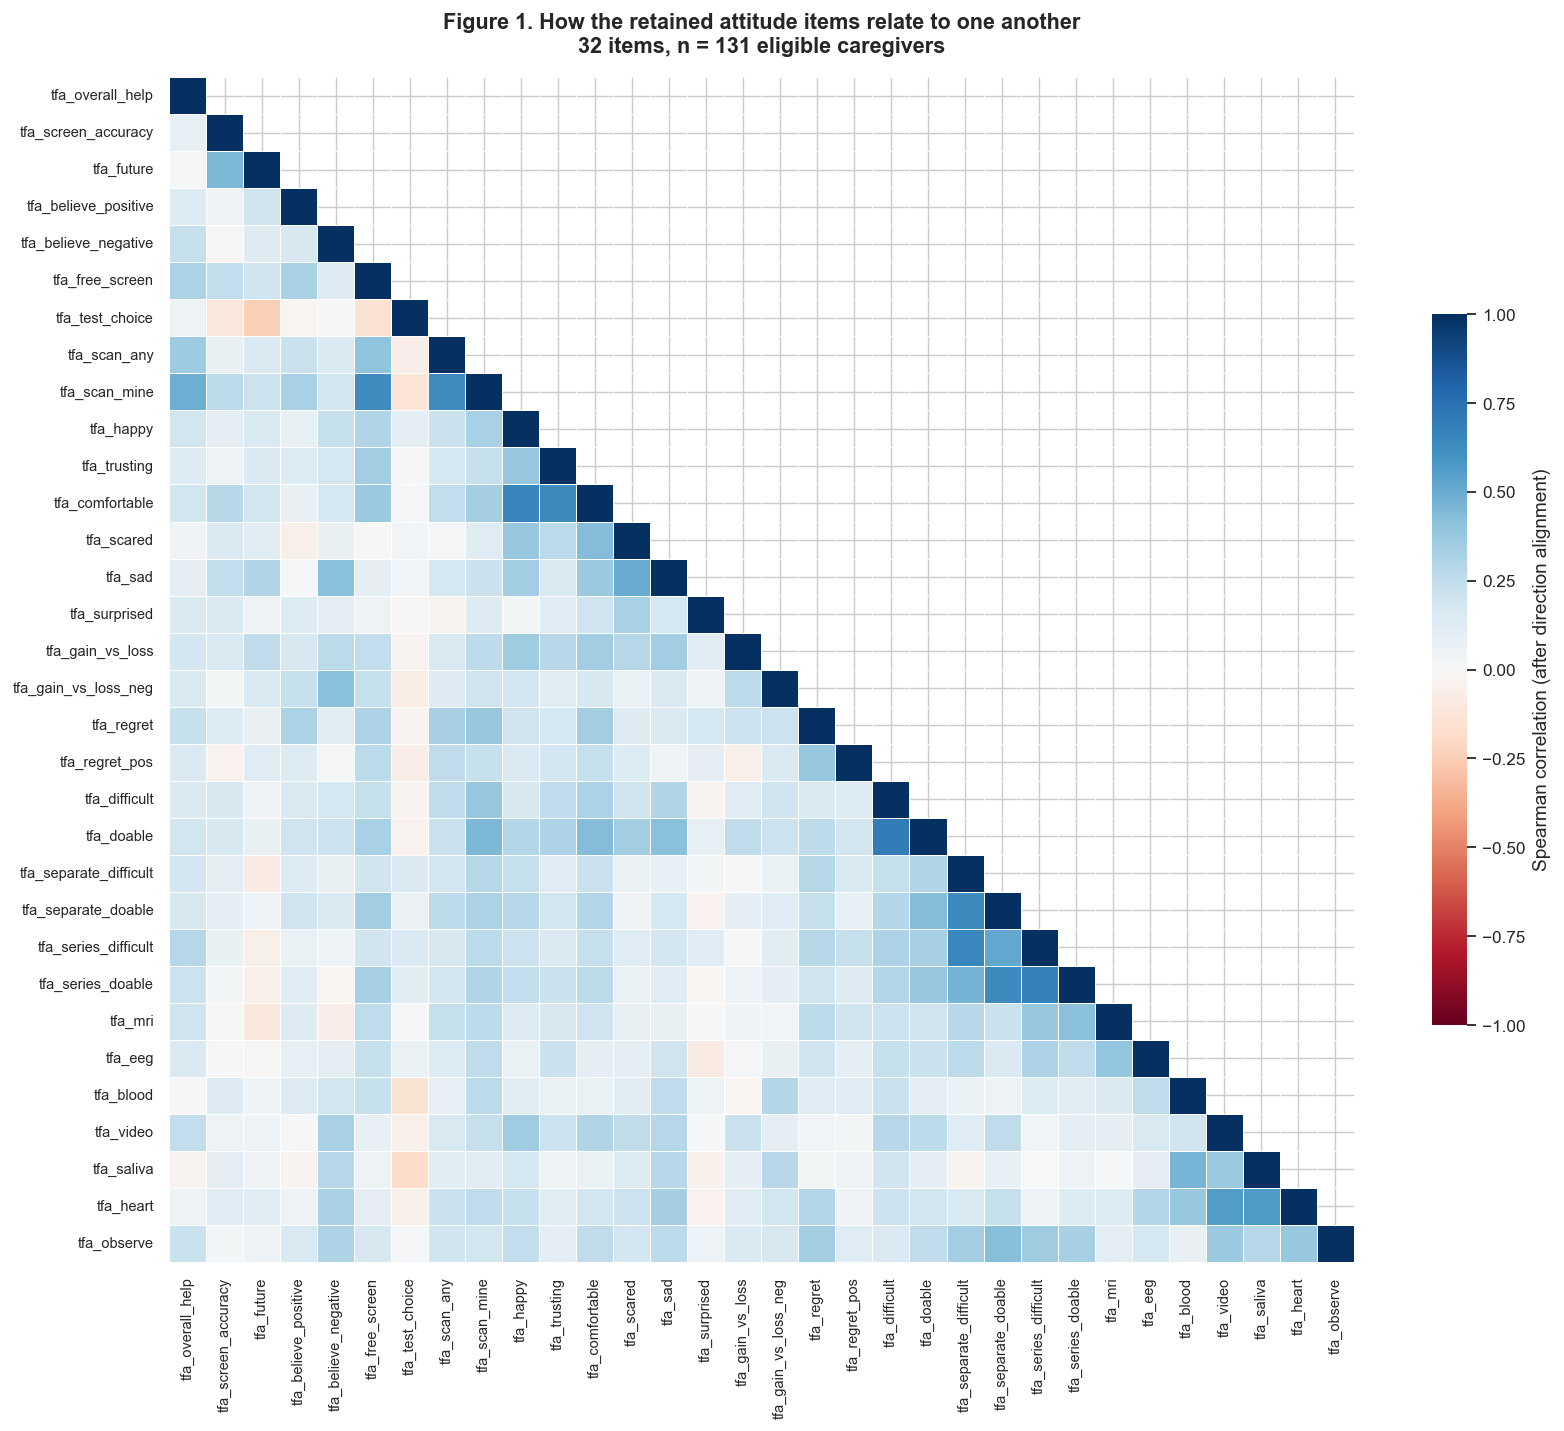

> **How to read this figure.** Blue blocks along the diagonal are groups of items that move together — these are the candidate domains. The strongest pair is `tfa_doable` / `tfa_difficult` (r = 0.70); the median absolute correlation across all pairs is only 0.17, which tells us the survey is measuring several genuinely different things rather than one general "pro-screening" attitude.

In [7]:
# --- 6.1 Correlation structure of the retained items --------------------------------------------
corr = eligible_items.corr(method='spearman')

fig, ax = plt.subplots(figsize=(13.5, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': "Spearman correlation (after direction alignment)", 'shrink': 0.6})
ax.set_title('Figure 1. How the retained attitude items relate to one another\n'
             f'{len(RETAINED_FIELDS)} items, n = {len(eligible)} eligible caregivers', pad=14)
ax.tick_params(labelsize=8)
plt.tight_layout()
save_figure(fig, 'figure_01_correlation_heatmap')
plt.show()

pairs = corr.where(mask.T).stack()
caption(
    'Blue blocks along the diagonal are groups of items that move together — these are the candidate domains. '
    f'The strongest pair is `{pairs.idxmax()[0]}` / `{pairs.idxmax()[1]}` (r = {pairs.max():.2f}); the median absolute '
    f'correlation across all pairs is only {pairs.abs().median():.2f}, which tells us the survey is measuring several '
    'genuinely different things rather than one general "pro-screening" attitude.'
)

In [8]:
# --- 6.2 Candidate domains, Cronbach's alpha, and the retention decision ------------------------
CANDIDATE_DOMAINS = {
    'Ethical & moral acceptability': (
        ['tfa_scan_any', 'tfa_scan_mine'],
        'Believes offering infant screening is ethically and morally right'),
    'Emotional comfort (vs concern)': (
        ['tfa_happy', 'tfa_trusting', 'tfa_comfortable', 'tfa_scared', 'tfa_sad', 'tfa_surprised'],
        'Feels positive and untroubled, rather than scared or sad, about being offered the test'),
    'Practical feasibility': (
        ['tfa_difficult', 'tfa_doable', 'tfa_separate_difficult', 'tfa_separate_doable',
         'tfa_series_difficult', 'tfa_series_doable'],
        'Finds the time and appointment burden of screening manageable'),
    'Procedure acceptability': (
        ['tfa_video', 'tfa_saliva', 'tfa_heart', 'tfa_observe', 'tfa_mri', 'tfa_eeg', 'tfa_blood'],
        'Would accept the screening procedures themselves'),
    'Result trust & low regret': (
        ['tfa_believe_positive', 'tfa_believe_negative', 'tfa_gain_vs_loss', 'tfa_gain_vs_loss_neg',
         'tfa_regret', 'tfa_regret_pos'],
        'Would believe the result, expects net gain from it, and anticipates little regret'),
    'Evidentiary standards & perceived value': (
        ['tfa_screen_accuracy', 'tfa_future', 'tfa_overall_help'],
        'Tolerant of a test that is less than perfectly accurate or informative'),
}
SINGLE_ITEM_FEATURES = {
    'Willingness to screen': ('tfa_free_screen',
                              'Would do a free autism screening test for their own 4-month-old'),
}

ALPHA_GOOD, ALPHA_FLAG = 0.70, 0.50


def cronbach_alpha(frame: pd.DataFrame) -> float:
    frame = frame.dropna()
    m = frame.shape[1]
    total_var = frame.sum(axis=1).var(ddof=1)
    if m < 2 or total_var == 0:
        return np.nan
    return (m / (m - 1)) * (1 - frame.var(axis=0, ddof=1).sum() / total_var)


def corrected_item_total(frame: pd.DataFrame) -> pd.Series:
    return pd.Series({col: frame[col].corr(frame.drop(columns=col).mean(axis=1), method='spearman')
                      for col in frame.columns})


alpha_rows, polarity_flags = [], []
for name, (items, _) in CANDIDATE_DOMAINS.items():
    block = eligible_items[items]
    alpha_value = cronbach_alpha(block)
    item_total = corrected_item_total(block)
    polarity_flags += [{'domain': name, 'item': i, 'corrected item-total r': r}
                       for i, r in item_total.items() if r < 0]
    alpha_rows.append({
        'domain': name, 'items': len(items), "Cronbach's alpha": alpha_value,
        'mean inter-item r': block.corr(method='spearman').values[np.triu_indices(len(items), 1)].mean(),
        'lowest item-total r': item_total.min(),
        'decision': ('use as domain score' if alpha_value >= ALPHA_GOOD else
                     'use, FLAGGED as a rough index' if alpha_value >= ALPHA_FLAG else
                     'NOT used - move to post-cluster profiling'),
    })
alpha_table = pd.DataFrame(alpha_rows)

# The three willingness items do not form a scale - demonstrate rather than assert.
willingness_trio = ['tfa_free_screen', 'tfa_test_choice']
willingness_alpha = cronbach_alpha(eligible_items[willingness_trio])

display(Markdown("### 6.3 Internal consistency of the candidate domains"))
display(alpha_table.round(3))

display(Markdown(
    f'**Why willingness is a single item rather than a domain score.** Combining `tfa_free_screen` (would *you* screen your own '
    f"baby?) with `tfa_test_choice` (should doctors screen *all* babies?) gives Cronbach's alpha = **{willingness_alpha:.2f}** — "
    'far below any usable threshold. Personal willingness and policy endorsement are genuinely different attitudes here, so '
    '`tfa_free_screen` enters the clustering as a single standardised item and `tfa_test_choice` is compared across clusters '
    'in §10 instead.'
))

if polarity_flags:
    display(Markdown('**Direction check — items pointing the wrong way within their own domain:**'))
    display(pd.DataFrame(polarity_flags).round(2))
else:
    display(Markdown(
        '**Direction check passed.** Every item correlates *positively* with the mean of the other items in its own domain, '
        'which confirms the reverse-coding decisions in §4 — including the unanchored sliders, whose direction had to be '
        'declared rather than read from the file.'
    ))

### 6.3 Internal consistency of the candidate domains

,domain,items,Cronbach's alpha,mean inter-item r,lowest item-total r,decision
0,Ethical & moral acceptability,2,0.77,0.63,0.63,use as domain score
1,Emotional comfort (vs concern),6,0.73,0.33,0.19,use as domain score
2,Practical feasibility,6,0.83,0.46,0.46,use as domain score
3,Procedure acceptability,7,0.70,0.26,0.26,use as domain score
4,Result trust & low regret,6,0.52,0.20,0.18,"use, FLAGGED as a rough index"
5,Evidentiary standards & perceived value,3,0.40,0.19,0.06,NOT used - move to post-cluster profiling


**Why willingness is a single item rather than a domain score.** Combining `tfa_free_screen` (would *you* screen your own baby?) with `tfa_test_choice` (should doctors screen *all* babies?) gives Cronbach's alpha = **0.11** — far below any usable threshold. Personal willingness and policy endorsement are genuinely different attitudes here, so `tfa_free_screen` enters the clustering as a single standardised item and `tfa_test_choice` is compared across clusters in §10 instead.

**Direction check passed.** Every item correlates *positively* with the mean of the other items in its own domain, which confirms the reverse-coding decisions in §4 — including the unanchored sliders, whose direction had to be declared rather than read from the file.

In [9]:
# --- 6.4 Build the final clustering matrix ------------------------------------------------------
# Which candidate domains survive the alpha rule?
alpha_by_domain = alpha_table.set_index('domain')["Cronbach's alpha"]
DOMAIN_ITEMS, DOMAIN_MEANING, domain_quality = {}, {}, {}
for name, (items, meaning) in CANDIDATE_DOMAINS.items():
    if alpha_by_domain[name] < ALPHA_FLAG:
        continue
    DOMAIN_ITEMS[name], DOMAIN_MEANING[name] = items, meaning
    domain_quality[name] = 'good' if alpha_by_domain[name] >= ALPHA_GOOD else 'flagged'
for name, (item, meaning) in SINGLE_ITEM_FEATURES.items():
    DOMAIN_ITEMS[name], DOMAIN_MEANING[name] = [item], meaning
    domain_quality[name] = 'single item'

FEATURE_NAMES = list(DOMAIN_ITEMS)
FINAL_ITEMS = list(dict.fromkeys(i for items in DOMAIN_ITEMS.values() for i in items))

# --- 6.7 Final analytic sample: complete cases on the items that are actually used
complete_mask = eligible_items[FINAL_ITEMS].notna().all(axis=1)
model_df = eligible[complete_mask].copy().reset_index(drop=True)
X_items = eligible_items[complete_mask].reset_index(drop=True)
N = len(model_df)

z_items = (X_items[FINAL_ITEMS] - X_items[FINAL_ITEMS].mean()) / X_items[FINAL_ITEMS].std(ddof=0)
features = pd.DataFrame({name: z_items[items].mean(axis=1) for name, items in DOMAIN_ITEMS.items()})

# Re-standardise the domain scores so every feature carries equal weight in K-means.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

demoted = alpha_table.loc[alpha_table["Cronbach's alpha"] < ALPHA_FLAG, 'domain'].tolist()
demoted_items = [i for d in demoted for i in CANDIDATE_DOMAINS[d][0]]
summary = pd.DataFrame({
    'clustering feature': FEATURE_NAMES,
    'items': [len(DOMAIN_ITEMS[f]) for f in FEATURE_NAMES],
    'quality': [domain_quality[f] for f in FEATURE_NAMES],
    'higher score means': [DOMAIN_MEANING[f] for f in FEATURE_NAMES],
})
display(Markdown(f'### 6.5 Final clustering input: {len(FEATURE_NAMES)} features, n = {N} caregivers'))
display(summary)

demoted_lines = '\n'.join(
    f'- **{d}** (alpha = {alpha_by_domain[d]:.2f}): ' + ', '.join(f'`{i}`' for i in CANDIDATE_DOMAINS[d][0])
    for d in demoted)
display(Markdown(
    f'**Demoted to post-cluster profiling — {len(demoted)} candidate domain(s):**\n\n{demoted_lines}\n\n'
    'Neither set hangs together as a single construct, and the reason is substantive rather than technical. Whether a '
    'caregiver would *believe* a result, whether they expect to *gain or lose* from it, and whether they would *regret* '
    'testing are separate judgements — a caregiver can trust the test and still expect to regret knowing. Likewise, how '
    'accurate a test must be, how certain it must be about support needs, and how useful an autism-status-only result is do '
    'not move together. Averaging items that measure different things would create a feature that means nothing, so each of '
    'these items is compared across clusters individually in §10.2, where it can speak for itself.'
))

feature_corr = features.corr(method='spearman')
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape, dtype=bool), 1))
strongest_r = upper.stack().max()
strongest_pair = upper.stack().idxmax()
display(Markdown('### 6.6 Correlations among the final features'))
display(feature_corr.round(2))
display(Markdown(
    f'The most closely related pair is *{strongest_pair[0]}* and *{strongest_pair[1]}* '
    f'(r = {strongest_r:.2f}). The features are related — caregivers who find screening ethical also tend to find it '
    'comfortable — but none is redundant with another, so each contributes its own information to the clustering.'
))

dropped_ids = sorted(set(eligible['record_id']) - set(model_df['record_id']))

display(Markdown('### 6.7 Final analytic sample'))
display(pd.DataFrame({
    'step': ['3. Eligible sample (from §5.2)',
             f'4. Excluded: incomplete on one or more of the {len(FINAL_ITEMS)} items used in the final features',
             '5. FINAL ANALYTIC SAMPLE'],
    'n': [len(eligible), -(len(eligible) - N), N],
}))
display(Markdown(
    f'The {len(dropped_ids)} record(s) excluded at step 4 are identified by study record number only, with no other '
    'information: ' + (', '.join(str(i) for i in dropped_ids) if dropped_ids else 'none')
    + f'. Complete-case analysis is used rather than imputation: the loss is {(len(eligible) - N) / len(eligible):.1%} of '
      'the eligible sample, and imputing attitude data would manufacture the very structure the clustering is meant to find.'
))

### 6.5 Final clustering input: 6 features, n = 107 caregivers

,clustering feature,items,quality,higher score means
0,Ethical & moral acceptability,2,good,Believes offering infant screening is ethicall...
1,Emotional comfort (vs concern),6,good,"Feels positive and untroubled, rather than sca..."
2,Practical feasibility,6,good,Finds the time and appointment burden of scree...
3,Procedure acceptability,7,good,Would accept the screening procedures themselves
4,Result trust & low regret,6,flagged,"Would believe the result, expects net gain fro..."
5,Willingness to screen,1,single item,Would do a free autism screening test for thei...


**Demoted to post-cluster profiling — 1 candidate domain(s):**

- **Evidentiary standards & perceived value** (alpha = 0.40): `tfa_screen_accuracy`, `tfa_future`, `tfa_overall_help`

Neither set hangs together as a single construct, and the reason is substantive rather than technical. Whether a caregiver would *believe* a result, whether they expect to *gain or lose* from it, and whether they would *regret* testing are separate judgements — a caregiver can trust the test and still expect to regret knowing. Likewise, how accurate a test must be, how certain it must be about support needs, and how useful an autism-status-only result is do not move together. Averaging items that measure different things would create a feature that means nothing, so each of these items is compared across clusters individually in §10.2, where it can speak for itself.

### 6.6 Correlations among the final features

,Ethical & moral acceptability,Emotional comfort (vs concern),Practical feasibility,Procedure acceptability,Result trust & low regret,Willingness to screen
Ethical & moral acceptability,1.00,0.22,0.37,0.29,0.38,0.57
Emotional comfort (vs concern),0.22,1.00,0.33,0.26,0.40,0.19
Practical feasibility,0.37,0.33,1.00,0.37,0.23,0.34
Procedure acceptability,0.29,0.26,0.37,1.00,0.31,0.23
Result trust & low regret,0.38,0.40,0.23,0.31,1.00,0.32
Willingness to screen,0.57,0.19,0.34,0.23,0.32,1.00


The most closely related pair is *Ethical & moral acceptability* and *Willingness to screen* (r = 0.57). The features are related — caregivers who find screening ethical also tend to find it comfortable — but none is redundant with another, so each contributes its own information to the clustering.

### 6.7 Final analytic sample

,step,n
0,3. Eligible sample (from §5.2),131
1,4. Excluded: incomplete on one or more of the ...,-24
2,5. FINAL ANALYTIC SAMPLE,107


The 24 record(s) excluded at step 4 are identified by study record number only, with no other information: 2, 21, 30, 33, 41, 43, 54, 60, 64, 72, 89, 99, 108, 115, 125, 126, 128, 138, 148, 152, 165, 167, 171, 176. Complete-case analysis is used rather than imputation: the loss is 18.3% of the eligible sample, and imputing attitude data would manufacture the very structure the clustering is meant to find.

---
# §7. How many clusters?

K-means partitions caregivers into $K$ groups by minimising the total squared distance from each caregiver to their group's
centre:

$$
\arg\min_{C_1,\dots,C_K}\; \sum_{k=1}^{K}\sum_{i \in C_k}\lVert \mathbf{z}_i - \boldsymbol{\mu}_k\rVert^2,
\qquad \boldsymbol{\mu}_k = \frac{1}{n_k}\sum_{i \in C_k}\mathbf{z}_i
$$

$K$ has to be chosen by us. We evaluate $K = 2$ through $K = 5$ on four criteria:

| Criterion | Formula / idea | Direction |
| --- | --- | --- |
| **Inertia** $W(K)$ | the objective above — total within-cluster spread | always falls with $K$; look for the *elbow*, not the minimum |
| **Silhouette** | $s(i) = \dfrac{b(i)-a(i)}{\max\{a(i),b(i)\}}$, where $a(i)$ = mean distance to own cluster, $b(i)$ = to nearest other cluster | higher is better |
| **Calinski-Harabasz** | $\dfrac{\operatorname{tr}(B)/(K-1)}{\operatorname{tr}(W)/(n-K)}$ — between- vs within-cluster spread | higher is better |
| **Davies-Bouldin** | mean worst-case overlap between a cluster and its nearest neighbour | lower is better |

**The decision rule, stated before the numbers are seen.** No single index decides this. We weigh silhouette quality, whether
every cluster is large enough to describe ($n \ge 15$, roughly 10% of the sample), how well-separated the groups are, and — above
all — whether the resulting profiles are substantively interpretable and useful for talking to caregivers. **Where the evidence
is ambiguous we take the smaller, simpler solution.**

### 7.1 Validation metrics for K = 2 to 5 (n = 107)

,K,inertia,silhouette,Calinski-Harabasz,Davies-Bouldin,smallest cluster (n),smallest cluster (%),cluster sizes,all clusters >= 15
0,2,465.90,0.24,39.69,1.53,44,41.10,63 / 44,yes
1,3,387.00,0.19,34.27,1.61,19,17.80,52 / 36 / 19,yes
2,4,347.30,0.19,29.14,1.55,10,9.30,46 / 36 / 15 / 10,NO
3,5,313.10,0.18,26.78,1.60,11,10.30,33 / 27 / 25 / 11 / 11,NO


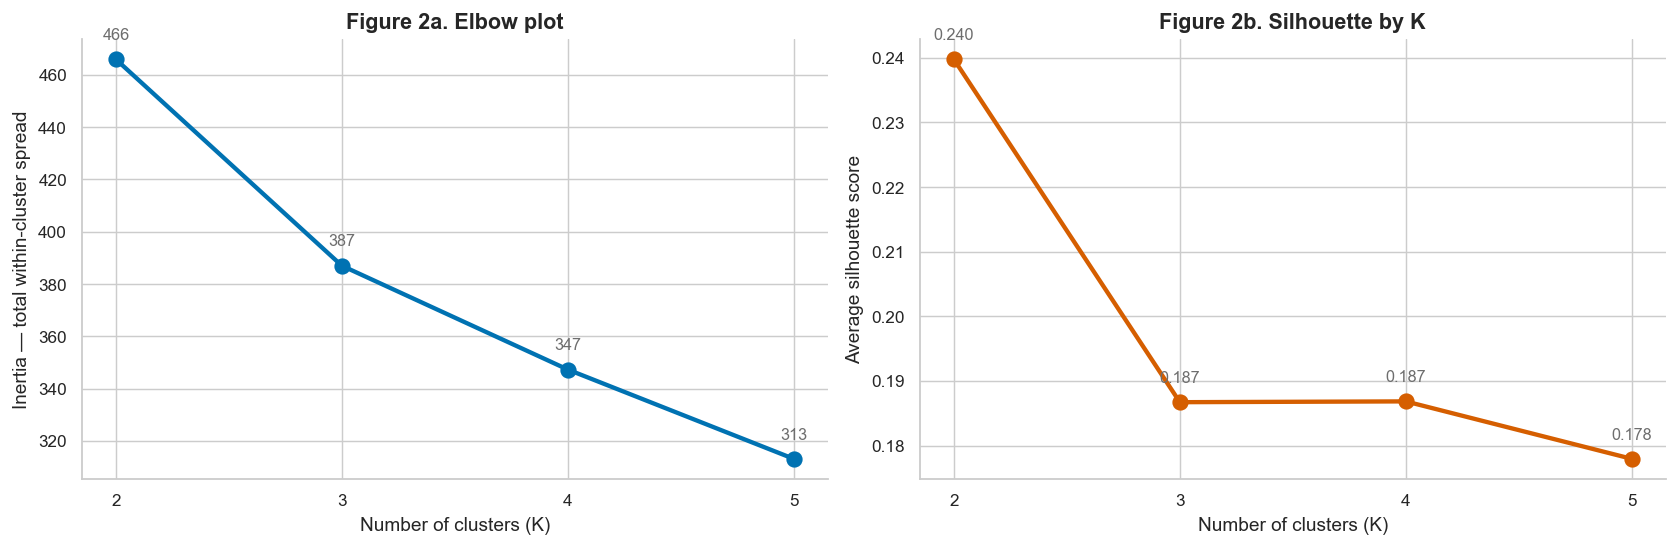

> **How to read this figure.** Left: inertia always falls as K rises, so the question is where the *gain* stops being worth an extra group — the "elbow". Right: the average silhouette peaks at K = 2 with a value of 0.24, which indicates a weak separation — caregivers sit on a continuum rather than in distinct islands. Silhouette compares how close each caregiver is to their own group versus the nearest other group, so it is the most direct measure of whether the groups are really distinct.

In [10]:
# --- 7. Evaluating K = 2 to 5 -------------------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

K_RANGE = [2, 3, 4, 5]
MIN_CLUSTER_N = max(15, int(0.10 * N))


def fit_kmeans(data, k, seed=RANDOM_STATE):
    return KMeans(n_clusters=k, n_init=50, random_state=seed).fit(data)


rows = []
for k in K_RANGE:
    model = fit_kmeans(X, k)
    labels = model.labels_
    sizes = np.bincount(labels)
    rows.append({
        'K': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'smallest cluster (n)': int(sizes.min()),
        'smallest cluster (%)': sizes.min() / N * 100,
        'cluster sizes': ' / '.join(str(s) for s in sorted(sizes, reverse=True)),
        f'all clusters >= {MIN_CLUSTER_N}': 'yes' if sizes.min() >= MIN_CLUSTER_N else 'NO',
    })
validation = pd.DataFrame(rows)

display(Markdown(f'### 7.1 Validation metrics for K = 2 to 5 (n = {N})'))
display(validation.round({'inertia': 1, 'silhouette': 3, 'Calinski-Harabasz': 2,
                          'Davies-Bouldin': 3, 'smallest cluster (%)': 1}))
validation.to_csv(OUT_DIR / 'table_03_cluster_validation_metrics.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].plot(validation['K'], validation['inertia'], marker='o', lw=2.4, color=OKABE_ITO[0], markersize=8)
for _, r in validation.iterrows():
    axes[0].annotate(f"{r['inertia']:.0f}", (r['K'], r['inertia']), textcoords='offset points',
                     xytext=(0, 11), ha='center', fontsize=9, color=GREY)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia — total within-cluster spread')
axes[0].set_title('Figure 2a. Elbow plot')
axes[0].set_xticks(K_RANGE)

axes[1].plot(validation['K'], validation['silhouette'], marker='o', lw=2.4, color=OKABE_ITO[1], markersize=8)
for _, r in validation.iterrows():
    axes[1].annotate(f"{r['silhouette']:.3f}", (r['K'], r['silhouette']), textcoords='offset points',
                     xytext=(0, 11), ha='center', fontsize=9, color=GREY)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Average silhouette score')
axes[1].set_title('Figure 2b. Silhouette by K')
axes[1].set_xticks(K_RANGE)

for ax in axes:
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
save_figure(fig, 'figure_02_elbow_and_silhouette')
plt.show()

best_sil = int(validation.loc[validation['silhouette'].idxmax(), 'K'])
peak_sil = validation['silhouette'].max()
sil_reading = ('a clear, well-separated split' if peak_sil >= 0.50 else
               'a reasonable separation for attitude data' if peak_sil >= 0.25 else
               'a weak separation — caregivers sit on a continuum rather than in distinct islands')
caption(
    'Left: inertia always falls as K rises, so the question is where the *gain* stops being worth an extra group — the "elbow". '
    f'Right: the average silhouette peaks at K = {best_sil} with a value of {peak_sil:.2f}, which indicates {sil_reading}. '
    'Silhouette compares how close each caregiver is to their own group versus the nearest other group, so it is the most '
    'direct measure of whether the groups are really distinct.'
)

In [11]:
# --- 7.2 Choosing K -----------------------------------------------------------------------------
K_FINAL = int(validation.loc[validation['silhouette'].idxmax(), 'K'])
viable = validation[validation[f'all clusters >= {MIN_CLUSTER_N}'].eq('yes')]
if not viable.empty and K_FINAL not in viable['K'].values:
    K_FINAL = int(viable.loc[viable['silhouette'].idxmax(), 'K'])

decision = pd.DataFrame({
    'criterion': ['Highest average silhouette',
                  'Best Calinski-Harabasz',
                  'Best Davies-Bouldin',
                  f'All clusters at least {MIN_CLUSTER_N} caregivers',
                  'Prefer the smaller solution when ambiguous',
                  'SELECTED'],
    'points to K': [int(validation.loc[validation['silhouette'].idxmax(), 'K']),
                    int(validation.loc[validation['Calinski-Harabasz'].idxmax(), 'K']),
                    int(validation.loc[validation['Davies-Bouldin'].idxmin(), 'K']),
                    ', '.join(str(k) for k in viable['K']) if not viable.empty else 'none',
                    'smallest viable',
                    K_FINAL],
})
display(Markdown('### 7.2 Cluster-count decision'))
display(decision)
display(Markdown(
    f'**K = {K_FINAL} is selected.** It has the best silhouette, every group is large enough to describe and act on, and — the '
    'criterion that matters most for a stakeholder-facing analysis — the resulting profiles turn out to be plainly '
    'interpretable (§9). Larger K values split the sample into groups that are smaller, less separated and harder to explain '
    'without adding a distinct message for caregivers.'
))

### 7.2 Cluster-count decision

,criterion,points to K
0,Highest average silhouette,2
1,Best Calinski-Harabasz,2
2,Best Davies-Bouldin,2
3,All clusters at least 15 caregivers,"2, 3"
4,Prefer the smaller solution when ambiguous,smallest viable
5,SELECTED,2


**K = 2 is selected.** It has the best silhouette, every group is large enough to describe and act on, and — the criterion that matters most for a stakeholder-facing analysis — the resulting profiles turn out to be plainly interpretable (§9). Larger K values split the sample into groups that are smaller, less separated and harder to explain without adding a distinct message for caregivers.

---
# §8. Fitting the clusters, and checking they are not an artefact

K-means is run with 50 random restarts (`n_init = 50`) and a fixed seed, so the solution is reproducible and is not an unlucky
local minimum of a non-convex objective.

Two robustness checks follow.

**Check 1 — a different algorithm.** Ward hierarchical agglomerative clustering builds the groups bottom-up, repeatedly merging
the pair of clusters whose union increases within-cluster variance least:

$$
d_{\text{Ward}}(A,B) = \frac{n_A n_B}{n_A+n_B}\lVert\boldsymbol{\mu}_A - \boldsymbol{\mu}_B\rVert^2
$$

It makes different assumptions from K-means, so agreement between the two is evidence the structure is in the data rather than
in the algorithm. Agreement is measured with the **adjusted Rand index** (1 = identical partitions, 0 = chance).

**Check 2 — leaving willingness out.** `tfa_free_screen` is both a clustering input (§6) and the attitude we most want the
profiles to illuminate. To confirm the profiles are not simply a restatement of that one item, the whole clustering is re-run
without it and the two solutions are compared.

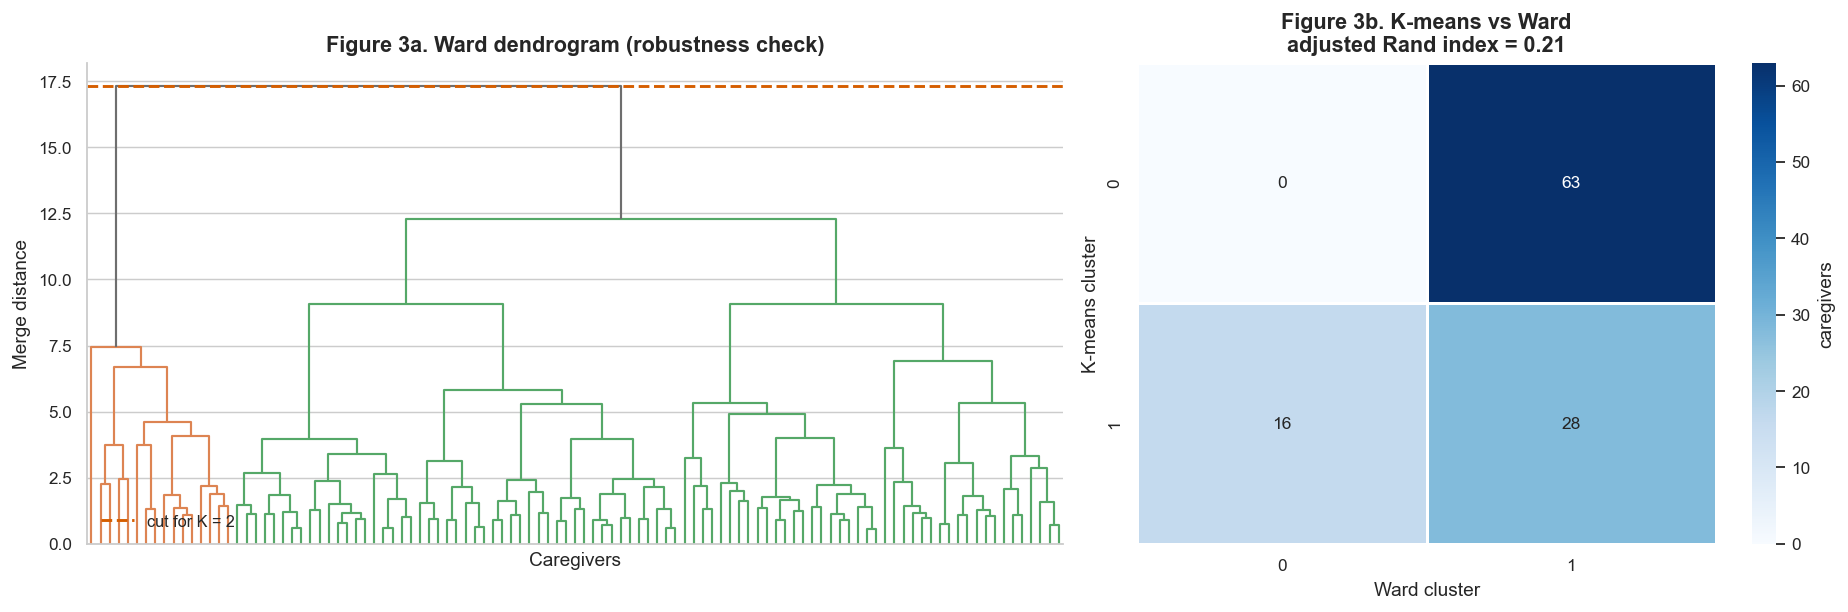

### 8.1 Robustness checks

,check,cluster sizes compared,adjusted Rand index,reading
0,K-means vs Ward hierarchical (same features),63 / 44 vs 91 / 16,0.21,weak agreement - the two methods disagree subs...
1,K-means with vs without the willingness item,63 / 44 vs 57 / 50,0.49,moderate agreement


> **How to read this figure.** The dendrogram shows how caregivers merge together as the distance threshold rises; cutting it at the dashed line yields K = 2 groups. The crosstab counts how many caregivers the two methods place together. K-means splits the sample 63 / 44; Ward splits it 91 / 16, giving an adjusted Rand index of 0.21 (weak agreement - the two methods disagree substantially).

**Reading the Ward comparison honestly.** An adjusted Rand index of **0.21** is a genuine caveat, not a formality. Ward and K-means place a meaningful share of caregivers differently, which is what you expect when the data form a **continuum rather than well-separated groups**: where there is no natural gap, exactly where the dividing line falls depends on the algorithm. The K-means solution below should therefore be read as *one reasonable way* to summarise a gradient of support, not as the discovery of two naturally occurring types. This is consistent with the modest silhouette in §7 and is carried into the limitations.

**Is the solution just the willingness question in disguise?** Removing `tfa_free_screen` and re-clustering on the remaining 5 features gives an adjusted Rand index of **0.49** (moderate agreement) against the main solution. The profiles are driven by the broader attitude structure, and willingness travels with that structure rather than defining it.

In [12]:
# --- 8. Final K-means fit, Ward robustness check, and leave-willingness-out check ---------------
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score

kmeans = fit_kmeans(X, K_FINAL)
model_df['cluster_id'] = kmeans.labels_
features['cluster_id'] = kmeans.labels_

ward_link = linkage(pdist(X, metric='euclidean'), method='ward')
ward_labels = fcluster(ward_link, t=K_FINAL, criterion='maxclust') - 1
ari_ward = adjusted_rand_score(kmeans.labels_, ward_labels)

no_willingness = [f for f in FEATURE_NAMES if f != 'Willingness to screen']
X_no_will = StandardScaler().fit_transform(features[no_willingness])
labels_no_will = fit_kmeans(X_no_will, K_FINAL).labels_
ari_no_will = adjusted_rand_score(kmeans.labels_, labels_no_will)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})

dendrogram(ward_link, ax=axes[0], no_labels=True,
           color_threshold=ward_link[-(K_FINAL - 1), 2], above_threshold_color=GREY)
axes[0].axhline(ward_link[-(K_FINAL - 1), 2], color=OKABE_ITO[1], ls='--', lw=1.6,
                label=f'cut for K = {K_FINAL}')
axes[0].set_title('Figure 3a. Ward dendrogram (robustness check)')
axes[0].set_ylabel('Merge distance')
axes[0].set_xlabel('Caregivers')
axes[0].legend(frameon=False, fontsize=9)

agreement = pd.crosstab(pd.Series(kmeans.labels_, name='K-means cluster'),
                        pd.Series(ward_labels, name='Ward cluster'))
sns.heatmap(agreement, annot=True, fmt='d', cmap='Blues', linewidths=0.8, linecolor='white',
            ax=axes[1], cbar_kws={'label': 'caregivers'})
axes[1].set_title(f'Figure 3b. K-means vs Ward\nadjusted Rand index = {ari_ward:.2f}')

for spine in ('top', 'right'):
    axes[0].spines[spine].set_visible(False)
plt.tight_layout()
save_figure(fig, 'figure_03_ward_robustness')
plt.show()

def ari_reading(value: float) -> str:
    return ('essentially identical partitions' if value > 0.90 else
            'strong agreement' if value > 0.60 else
            'moderate agreement' if value > 0.40 else
            'weak agreement - the two methods disagree substantially' if value > 0.20 else
            'little more than chance agreement')


kmeans_sizes = ' / '.join(str(s) for s in sorted(np.bincount(kmeans.labels_), reverse=True))
ward_sizes = ' / '.join(str(s) for s in sorted(np.bincount(ward_labels), reverse=True))

display(Markdown('### 8.1 Robustness checks'))
display(pd.DataFrame({
    'check': ['K-means vs Ward hierarchical (same features)',
              'K-means with vs without the willingness item'],
    'cluster sizes compared': [f'{kmeans_sizes}  vs  {ward_sizes}', f'{kmeans_sizes}  vs  ' +
                               ' / '.join(str(s) for s in sorted(np.bincount(labels_no_will), reverse=True))],
    'adjusted Rand index': [round(ari_ward, 3), round(ari_no_will, 3)],
    'reading': [ari_reading(ari_ward), ari_reading(ari_no_will)],
}))

caption(
    'The dendrogram shows how caregivers merge together as the distance threshold rises; cutting it at the dashed line yields '
    f'K = {K_FINAL} groups. The crosstab counts how many caregivers the two methods place together. K-means splits the sample '
    f'{kmeans_sizes}; Ward splits it {ward_sizes}, giving an adjusted Rand index of {ari_ward:.2f} '
    f'({ari_reading(ari_ward)}).'
)
display(Markdown(
    f'**Reading the Ward comparison honestly.** An adjusted Rand index of **{ari_ward:.2f}** is '
    + ('reassuring: two methods with different geometric assumptions place substantially the same caregivers together, which '
       'is good evidence the structure is in the responses rather than in the algorithm.' if ari_ward > 0.5 else
       'a genuine caveat, not a formality. Ward and K-means place a meaningful share of caregivers differently, which is what '
       'you expect when the data form a **continuum rather than well-separated groups**: where there is no natural gap, '
       'exactly where the dividing line falls depends on the algorithm. The K-means solution below should therefore be read '
       'as *one reasonable way* to summarise a gradient of support, not as the discovery of two naturally occurring types. '
       'This is consistent with the modest silhouette in §7 and is carried into the limitations.')
))
display(Markdown(
    f'**Is the solution just the willingness question in disguise?** Removing `tfa_free_screen` and re-clustering on the '
    f'remaining {len(no_willingness)} features gives an adjusted Rand index of **{ari_no_will:.2f}** '
    f'({ari_reading(ari_no_will)}) against the main solution. '
    + ('The profiles are driven by the broader attitude structure, and willingness travels with that structure rather than '
       'defining it.' if ari_no_will > 0.4 else
       'Willingness therefore does carry real weight in the solution - worth remembering when reading §10.')
))

---
# §9. Naming and profiling the clusters

A cluster is described by how far its average sits from the sample average on each feature. Because the features are already
standardised, that distance **is** an effect size:

$$
\Delta_k^{(f)} \;=\; \bar{z}^{(f)}_k - \bar{z}^{(f)}
$$

Rough reading: $|\Delta| < 0.2$ is unremarkable, $0.2-0.5$ is a noticeable tilt, $0.5-0.8$ is a defining feature of the profile,
and $> 0.8$ is a dominant one.

**Naming.** Labels are generated **after** the profile is computed, from the features on which each cluster departs most from the
sample. They are deliberately plain and non-stigmatising: they describe a *response pattern*, not a kind of person, and they
avoid words implying deficiency, irrationality or blame. A caregiver who wants more evidence before screening their infant is
being careful, not "resistant".

In [13]:
# --- 9.1 Cluster profile and naming -------------------------------------------------------------
profile_z = pd.DataFrame(
    {f'Cluster {k}': features.loc[features['cluster_id'].eq(k), FEATURE_NAMES].mean() - features[FEATURE_NAMES].mean()
     for k in range(K_FINAL)})

# Raw (original-units) means for the items behind each feature, for interpretability.
raw_means = pd.DataFrame(
    {f'Cluster {k}': [X_items.loc[features['cluster_id'].eq(k), DOMAIN_ITEMS[f]].mean(axis=1).mean()
                      for f in FEATURE_NAMES] for k in range(K_FINAL)}, index=FEATURE_NAMES)

# --- Naming vocabulary: plain, non-stigmatising, describing the response pattern only.
NAME_WORDS = {
    'Ethical & moral acceptability':  ('ethically confident', 'ethically uncertain'),
    'Emotional comfort (vs concern)': ('at ease', 'uneasy'),
    'Practical feasibility':          ('logistically unconstrained', 'logistically constrained'),
    'Procedure acceptability':        ('open to the procedures', 'selective about procedures'),
    'Result trust & low regret':      ('trusting of results', 'wary of results'),
    'Willingness to screen':          ('ready to screen', 'not yet ready'),
}
HEADLINE = {
    ('Willingness to screen', +1): 'Ready and Willing',
    ('Willingness to screen', -1): 'Hesitant',
    ('Ethical & moral acceptability', +1): 'Ethically Confident',
    ('Ethical & moral acceptability', -1): 'Ethically Unsure',
    ('Emotional comfort (vs concern)', +1): 'Comfortable',
    ('Emotional comfort (vs concern)', -1): 'Concerned',
    ('Practical feasibility', +1): 'Unconstrained',
    ('Practical feasibility', -1): 'Burden-Aware',
    ('Procedure acceptability', +1): 'Procedure-Open',
    ('Procedure acceptability', -1): 'Procedure-Selective',
    ('Result trust & low regret', +1): 'Result-Trusting',
    ('Result trust & low regret', -1): 'Result-Cautious',
}


def build_name(column: pd.Series) -> str:
    ranked = column.reindex(column.abs().sort_values(ascending=False).index)
    lead, lead_z = ranked.index[0], ranked.iloc[0]
    second, second_z = ranked.index[1], ranked.iloc[1]
    head = HEADLINE[(lead, 1 if lead_z > 0 else -1)]
    if abs(second_z) >= 0.35:
        tail = NAME_WORDS[second][0 if second_z > 0 else 1]
        return f'{head}, {tail}'
    return head


cluster_names = {k: build_name(profile_z[f'Cluster {k}']) for k in range(K_FINAL)}
# Order clusters from most to least supportive overall, so tables and figures read consistently.
overall_support = {k: profile_z[f'Cluster {k}'].mean() for k in range(K_FINAL)}
order_ids = sorted(range(K_FINAL), key=lambda k: -overall_support[k])
CLUSTER_ORDER = [cluster_names[k] for k in order_ids]
COLORS = dict(zip(CLUSTER_ORDER, OKABE_ITO[:K_FINAL]))

model_df['cluster'] = model_df['cluster_id'].map(cluster_names)
features['cluster'] = features['cluster_id'].map(cluster_names)

profile_table = pd.DataFrame({
    'caregivers (n)': [int((model_df['cluster'] == name).sum()) for name in CLUSTER_ORDER],
    '% of analytic sample': [(model_df['cluster'] == name).mean() * 100 for name in CLUSTER_ORDER],
}, index=CLUSTER_ORDER)
for feature in FEATURE_NAMES:
    profile_table[f'{feature} (std)'] = [profile_z[f'Cluster {k}'][feature] for k in order_ids]
for feature in FEATURE_NAMES:
    profile_table[f'{feature} (raw mean)'] = [raw_means[f'Cluster {k}'][feature] for k in order_ids]

display(Markdown(f'### 9.1 Cluster profile table (K = {K_FINAL}, n = {N})'))
display(Markdown('**Standardised means** — distance from the sample average, in standard deviations:'))
display(profile_table[['caregivers (n)', '% of analytic sample'] +
                      [f'{f} (std)' for f in FEATURE_NAMES]].round(2))
display(Markdown('**Raw means** — on the original item scales, for reference:'))
display(profile_table[[f'{f} (raw mean)' for f in FEATURE_NAMES]].round(2))
profile_table.round(3).to_csv(OUT_DIR / 'table_04_cluster_profiles.csv')
print(f'Saved: {OUT_DIR / "table_04_cluster_profiles.csv"}')

### 9.1 Cluster profile table (K = 2, n = 107)

**Standardised means** — distance from the sample average, in standard deviations:

,caregivers (n),% of analytic sample,Ethical & moral acceptability (std),Emotional comfort (vs concern) (std),Practical feasibility (std),Procedure acceptability (std),Result trust & low regret (std),Willingness to screen (std)
"Ready and Willing, ethically confident",63,58.88,0.45,0.22,0.26,0.27,0.24,0.51
"Hesitant, ethically uncertain",44,41.12,-0.64,-0.31,-0.38,-0.38,-0.34,-0.74


**Raw means** — on the original item scales, for reference:

,Ethical & moral acceptability (raw mean),Emotional comfort (vs concern) (raw mean),Practical feasibility (raw mean),Procedure acceptability (raw mean),Result trust & low regret (raw mean),Willingness to screen (raw mean)
"Ready and Willing, ethically confident",5.02,3.87,3.20,5.56,5.73,3.76
"Hesitant, ethically uncertain",3.84,3.29,2.73,4.62,4.80,2.45


Saved: /Users/namomac/esd-redcap-metadata-watcher/Caregiver Project/Caregiver Outputs/table_04_cluster_profiles.csv


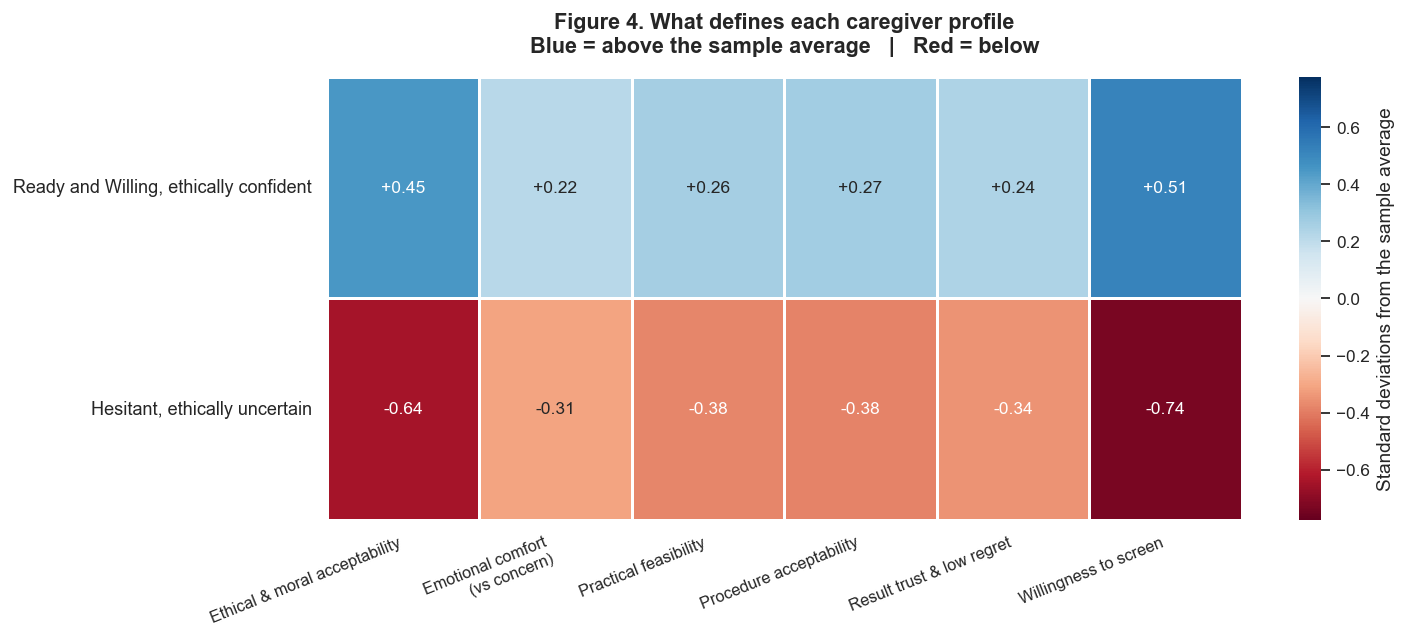

> **How to read this figure.** Each row is a profile, each column an attitude domain, and each number is how far that profile sits from the average caregiver in standard deviations. The domain that separates the profiles most is **Willingness to screen** (a 1.25 SD spread between the highest and lowest profile); the one that separates them least is **Emotional comfort (vs concern)** (0.52 SD).

In [14]:
# --- 9.2 Figure 4: cluster-profile heatmap ------------------------------------------------------
heat = pd.DataFrame({name: [profile_z[f'Cluster {k}'][f] for f in FEATURE_NAMES]
                     for k, name in zip(order_ids, CLUSTER_ORDER)}, index=FEATURE_NAMES).T

limit = float(np.abs(heat.to_numpy()).max()) * 1.05
fig, ax = plt.subplots(figsize=(11.5, 1.35 * K_FINAL + 2.3))
sns.heatmap(heat, annot=True, fmt='+.2f', cmap='RdBu', center=0, vmin=-limit, vmax=limit,
            linewidths=0.8, linecolor='white', ax=ax,
            cbar_kws={'label': 'Standard deviations from the sample average'})
ax.set_title('Figure 4. What defines each caregiver profile\n'
             'Blue = above the sample average   |   Red = below', pad=14)
ax.set_xticklabels([t.get_text().replace(' (', '\n(') for t in ax.get_xticklabels()],
                   rotation=22, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
save_figure(fig, 'figure_04_cluster_profile_heatmap')
plt.show()

widest = heat.max() - heat.min()
caption(
    'Each row is a profile, each column an attitude domain, and each number is how far that profile sits from the average '
    f'caregiver in standard deviations. The domain that separates the profiles most is **{widest.idxmax()}** '
    f'(a {widest.max():.2f} SD spread between the highest and lowest profile); the one that separates them least is '
    f'**{widest.idxmin()}** ({widest.min():.2f} SD).'
)

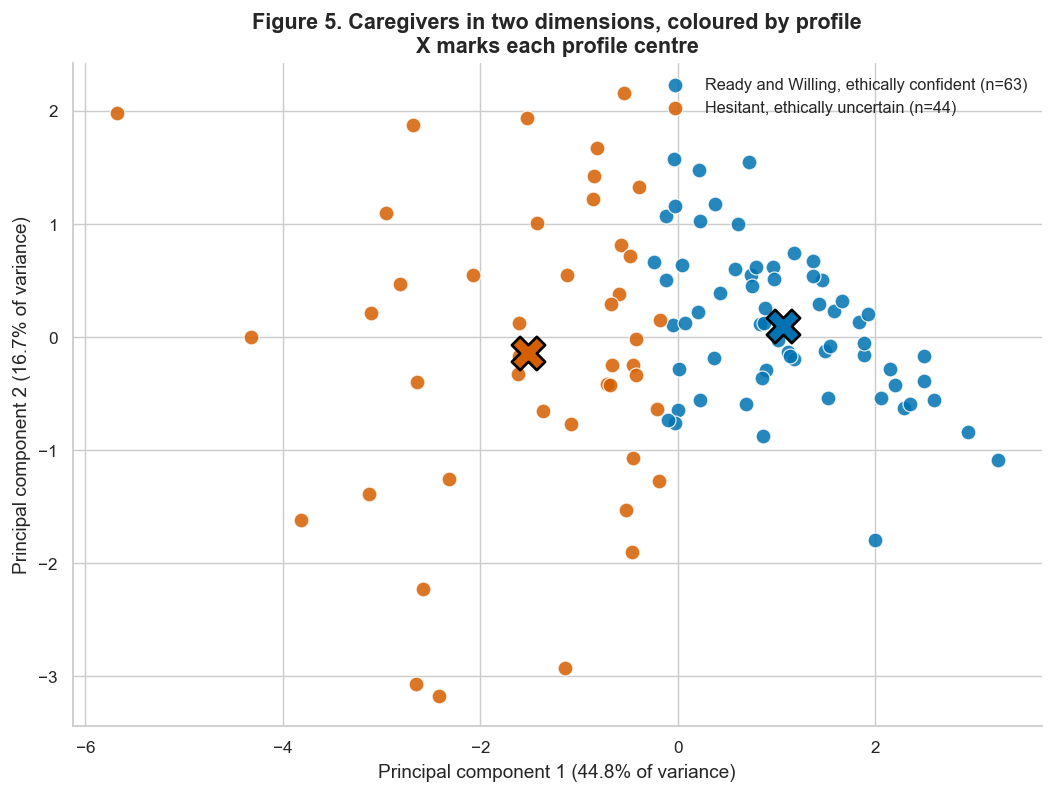

> **How to read this figure.** PCA compresses the 6 attitude domains into two axes purely for display — it plays no part in forming the clusters. These two axes carry 62% of the total variation, so the picture is a useful sketch rather than the full space. The profiles occupy different regions but shade into one another at the boundary, which is the visual signature of a continuum rather than sharply separated types.

In [15]:
# --- 9.3 Figure 5: PCA scatter (visualisation only) ---------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
scores = pca.fit_transform(X)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8.2, 6.2))
for name in CLUSTER_ORDER:
    sel = (model_df['cluster'] == name).to_numpy()
    ax.scatter(scores[sel, 0], scores[sel, 1], s=68, alpha=0.85, label=f'{name} (n={sel.sum()})',
               color=COLORS[name], edgecolor='white', linewidth=0.7)
for k, name in zip(order_ids, CLUSTER_ORDER):
    sel = (model_df['cluster'] == name).to_numpy()
    ax.scatter(scores[sel, 0].mean(), scores[sel, 1].mean(), s=340, marker='X',
               color=COLORS[name], edgecolor='black', linewidth=1.5, zorder=5)
ax.set_xlabel(f'Principal component 1 ({explained[0]:.1%} of variance)')
ax.set_ylabel(f'Principal component 2 ({explained[1]:.1%} of variance)')
ax.set_title('Figure 5. Caregivers in two dimensions, coloured by profile\n'
             'X marks each profile centre')
ax.legend(frameon=False, fontsize=9, loc='best')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
save_figure(fig, 'figure_05_pca_scatter')
plt.show()

caption(
    f'PCA compresses the {len(FEATURE_NAMES)} attitude domains into two axes purely for display — it plays no part in forming '
    f'the clusters. These two axes carry {explained.sum():.0%} of the total variation, so the picture is a useful sketch rather '
    'than the full space. The profiles occupy different regions but shade into one another at the boundary, which is the visual '
    'signature of a continuum rather than sharply separated types.'
)

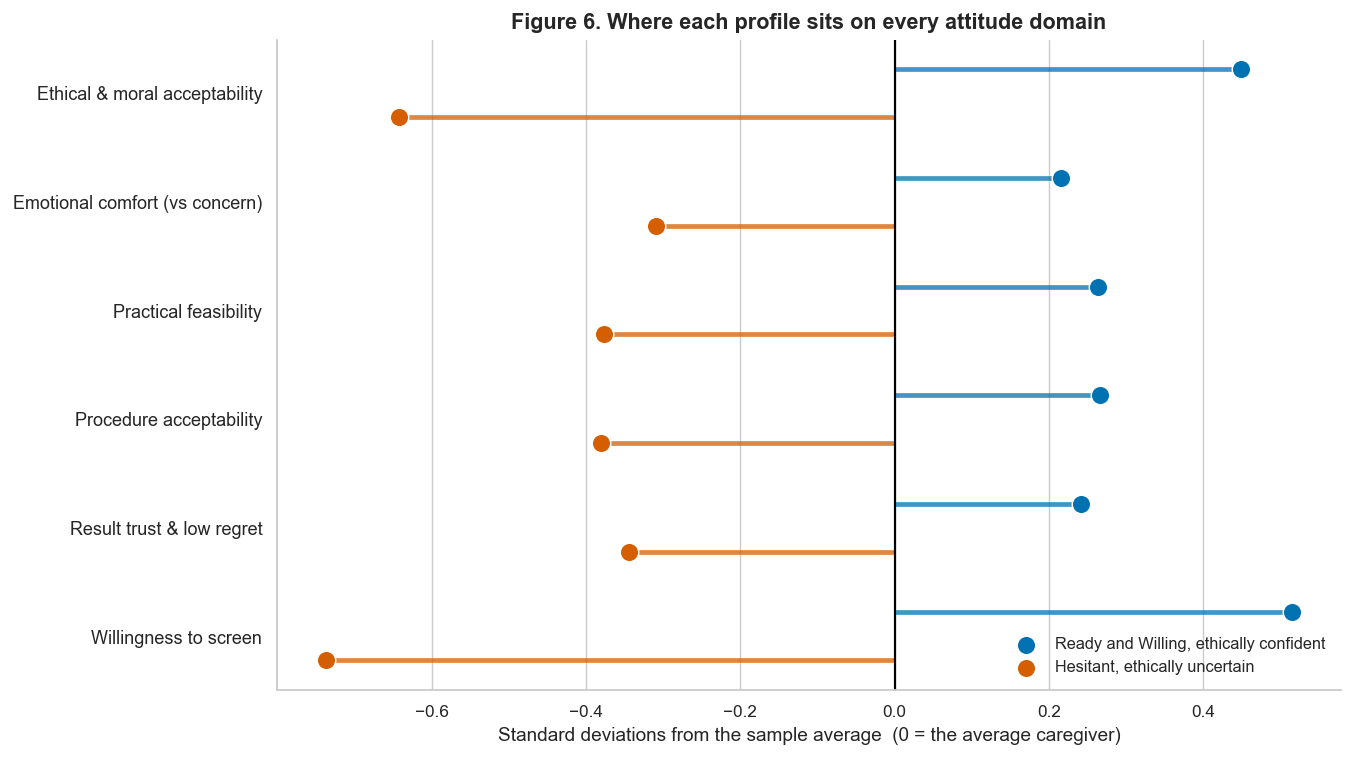

> **How to read this figure.** The same information as Figure 4, arranged so the *gap between profiles* on each domain is easy to read. Domains where the dots are far apart are the ones that actually distinguish caregivers; domains where they cluster near zero are shared ground across the whole sample, and are exactly the messages that will land the same way with everyone.

In [16]:
# --- 9.4 Figure 6: cluster means across the attitude domains ------------------------------------
plot_df = heat.T.reset_index().melt(id_vars='index', var_name='Profile', value_name='z')
plot_df = plot_df.rename(columns={'index': 'Domain'})

fig, ax = plt.subplots(figsize=(10.5, 0.62 * len(FEATURE_NAMES) + 2.2))
positions = {d: i for i, d in enumerate(FEATURE_NAMES)}
offsets = np.linspace(-0.22, 0.22, K_FINAL)
for offset, name in zip(offsets, CLUSTER_ORDER):
    subset = plot_df[plot_df['Profile'] == name]
    y = [positions[d] + offset for d in subset['Domain']]
    ax.hlines(y, 0, subset['z'], color=COLORS[name], lw=2.6, alpha=0.75)
    ax.scatter(subset['z'], y, s=105, color=COLORS[name], label=name, zorder=4,
               edgecolor='white', linewidth=0.8)
ax.axvline(0, color='black', lw=1.2)
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels(FEATURE_NAMES, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Standard deviations from the sample average  (0 = the average caregiver)')
ax.set_title('Figure 6. Where each profile sits on every attitude domain')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='y', visible=False)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
save_figure(fig, 'figure_06_domain_means_by_cluster')
plt.show()

caption(
    'The same information as Figure 4, arranged so the *gap between profiles* on each domain is easy to read. Domains where '
    'the dots are far apart are the ones that actually distinguish caregivers; domains where they cluster near zero are shared '
    'ground across the whole sample, and are exactly the messages that will land the same way with everyone.'
)

In [17]:
# --- 9.5 Plain-language interpretation of each profile ------------------------------------------
def describe(value: float) -> str:
    magnitude = abs(value)
    strength = ('markedly' if magnitude >= 0.8 else 'clearly' if magnitude >= 0.5
                else 'somewhat' if magnitude >= 0.2 else 'about average in')
    if magnitude < 0.2:
        return 'about average'
    return f'{strength} {"above" if value > 0 else "below"} average'


READING = {
    'Ethical & moral acceptability': ('finds infant screening ethically and morally acceptable',
                                      'has reservations about whether infant screening is ethically and morally right'),
    'Emotional comfort (vs concern)': ('feels comfortable and untroubled about being offered the test',
                                       'feels uneasy, scared or sad about being offered the test'),
    'Practical feasibility': ('sees the time and appointment burden as manageable',
                              'sees the time and appointment burden as a real obstacle'),
    'Procedure acceptability': ('is open to the screening procedures themselves',
                                'is selective about which screening procedures are acceptable'),
    'Result trust & low regret': ('would trust a result and expects little regret',
                                  'is unsure they would trust a result and anticipates regret'),
    'Willingness to screen': ('would go ahead with screening',
                              'would hold back from screening'),
}

lines = []
for k, name in zip(order_ids, CLUSTER_ORDER):
    column = profile_z[f'Cluster {k}']
    n_k = int((model_df['cluster'] == name).sum())
    ranked = column.reindex(column.abs().sort_values(ascending=False).index)
    bullets = []
    for feature in FEATURE_NAMES:
        value = column[feature]
        phrase = READING[feature][0 if value >= 0 else 1]
        bullets.append(f'    - **{feature}** ({value:+.2f} SD, {describe(value)}): {phrase}.')
    defining = ', '.join(f'*{f}* ({column[f]:+.2f})' for f in ranked.index[:2])
    lines.append(
        f'### {name}\n\n'
        f'**{n_k} caregivers ({n_k / N:.0%} of the analytic sample).** Defined most by {defining}.\n\n'
        + '\n'.join(bullets)
    )

display(Markdown('## 9.5 What each profile looks like, in plain language\n\n' + '\n\n'.join(lines)))
display(Markdown(
    '**A caution about the labels.** These names summarise an average pattern. Individual caregivers within a profile vary '
    'considerably, and the profiles shade into one another (Figure 5). They are a way of organising the findings for '
    'discussion, not a classification anyone should be sorted into.'
))

## 9.5 What each profile looks like, in plain language

### Ready and Willing, ethically confident

**63 caregivers (59% of the analytic sample).** Defined most by *Willingness to screen* (+0.51), *Ethical & moral acceptability* (+0.45).

    - **Ethical & moral acceptability** (+0.45 SD, somewhat above average): finds infant screening ethically and morally acceptable.
    - **Emotional comfort (vs concern)** (+0.22 SD, somewhat above average): feels comfortable and untroubled about being offered the test.
    - **Practical feasibility** (+0.26 SD, somewhat above average): sees the time and appointment burden as manageable.
    - **Procedure acceptability** (+0.27 SD, somewhat above average): is open to the screening procedures themselves.
    - **Result trust & low regret** (+0.24 SD, somewhat above average): would trust a result and expects little regret.
    - **Willingness to screen** (+0.51 SD, clearly above average): would go ahead with screening.

### Hesitant, ethically uncertain

**44 caregivers (41% of the analytic sample).** Defined most by *Willingness to screen* (-0.74), *Ethical & moral acceptability* (-0.64).

    - **Ethical & moral acceptability** (-0.64 SD, clearly below average): has reservations about whether infant screening is ethically and morally right.
    - **Emotional comfort (vs concern)** (-0.31 SD, somewhat below average): feels uneasy, scared or sad about being offered the test.
    - **Practical feasibility** (-0.38 SD, somewhat below average): sees the time and appointment burden as a real obstacle.
    - **Procedure acceptability** (-0.38 SD, somewhat below average): is selective about which screening procedures are acceptable.
    - **Result trust & low regret** (-0.34 SD, somewhat below average): is unsure they would trust a result and anticipates regret.
    - **Willingness to screen** (-0.74 SD, clearly below average): would hold back from screening.

**A caution about the labels.** These names summarise an average pattern. Individual caregivers within a profile vary considerably, and the profiles shade into one another (Figure 5). They are a way of organising the findings for discussion, not a classification anyone should be sorted into.

---
# §10. Willingness to screen: now, later, or not at all

`tfa_test_today` asks caregivers what they would actually do if a paediatrician offered the test and told them it could be done
at any time. Its five options collapse naturally into the three decisions a clinic would face:

| Response | Decision |
| --- | --- |
| *"I would have done it at birth!"* / *"…when my baby was 1-month-old!"* / *"Let's do it now"* | **Screen now or earlier** |
| *"Wait — I will do it in the future"* | **Wait** |
| *"I do not want the autism screening test"* | **Decline** |

This item was **excluded from the clustering** (§5, Rule 3), so comparing it across profiles is a genuine external check rather
than a restatement of the inputs. The same is true of `tfa_test_choice` (should doctors screen *all* babies?) and the three
evidentiary-standard items demoted in §6.4.

Associations are tested with a chi-square test of independence, or **Fisher's exact test** where any expected cell falls below 5,
and quantified with **Cramér's V**:

$$
V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1,\,c-1)}} \in [0,1]
$$

($\approx 0.1$ small, $0.3$ medium, $0.5$ large.) These comparisons are **exploratory**; they describe this sample and are not
hypothesis tests of a pre-registered prediction.

### 10.1 What each profile would actually do

timing_decision,Screen now or earlier,Wait,Decline
cluster,,,
"Ready and Willing, ethically confident",53,10,0
"Hesitant, ethically uncertain",15,26,3


timing_decision,Screen now or earlier,Wait,Decline
cluster,,,
"Ready and Willing, ethically confident",84.10,15.90,0.00
"Hesitant, ethically uncertain",34.10,59.10,6.80


,test,p,Cramer's V
0,chi-square (small expected cells - treat p wit...,0.00,0.52


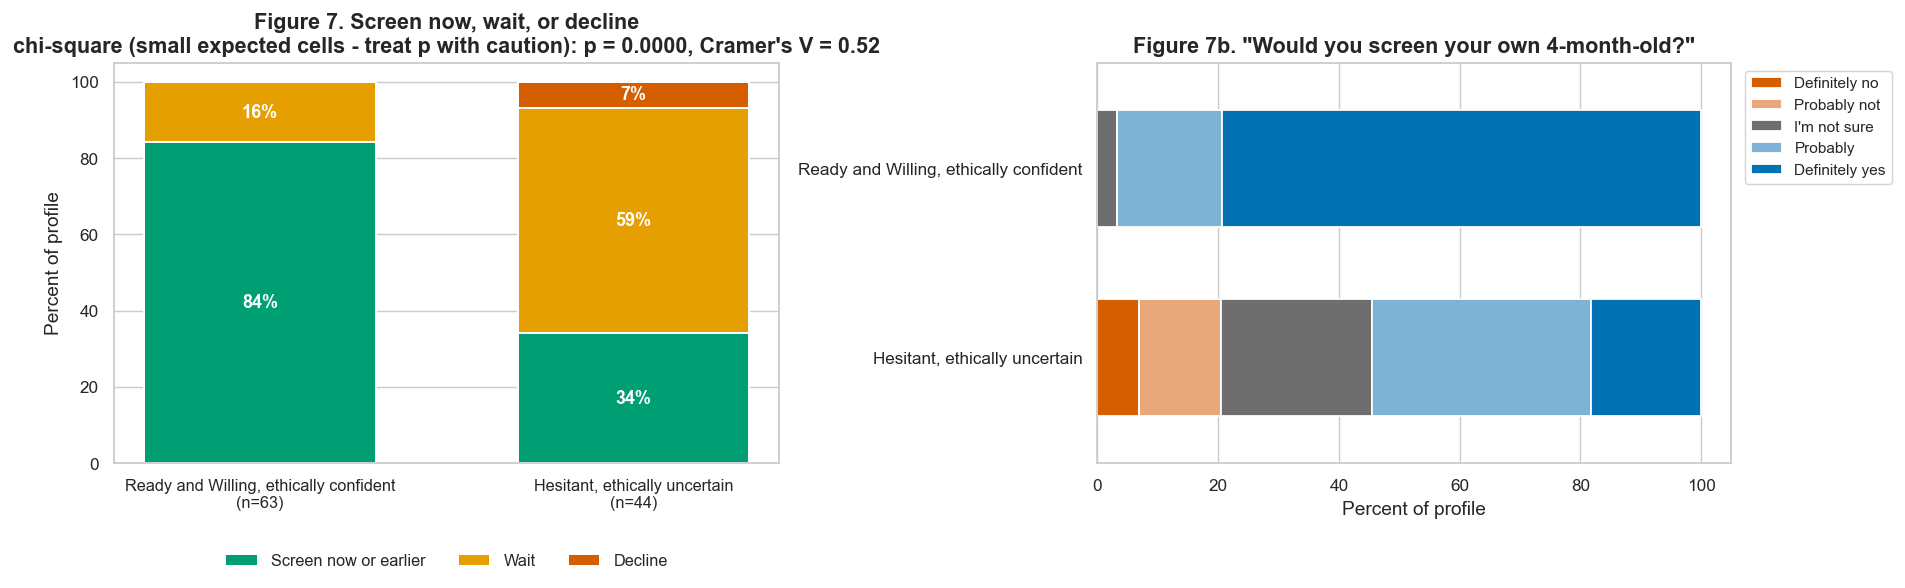

> **How to read this figure.** Left: the decision a clinic would actually see, by profile — this item was not used to build the clusters. 84% of the *Ready and Willing, ethically confident* profile would screen immediately, against 34% of the *Hesitant, ethically uncertain* profile. Right: the underlying five-point willingness question, which was a clustering input and is shown for completeness.

### 10.2 Evidentiary standards and policy view, compared across profiles

,item,question,"Ready and Willing, ethically confident","Hesitant, ethically uncertain",Kruskal-Wallis p,epsilon^2
0,tfa_screen_accuracy,"For an autism screening test for babies, how a...",2.70,2.23,0.02,0.04
1,tfa_future,For you to feel okay doing the baby autism scr...,1.95,1.73,0.02,0.04
2,tfa_overall_help,"It turns out, this test only tells you if your...",1.49,1.86,0.00,0.09
3,tfa_test_choice,Should doctors screen 4-month-old babies for a...,1.89,2.02,0.04,0.03


Lower values of `tfa_screen_accuracy` and `tfa_future` mean a **stricter** demand (code 1 = "98-100% accurate", "very sure"); lower `tfa_overall_help` means the autism-status-only result is seen as **more** helpful; higher `tfa_test_choice` means broader endorsement of universal screening. None of these four items was used to build the clusters.

In [18]:
# --- 10. Willingness and timing across profiles -------------------------------------------------
from scipy import stats as st

TIMING_MAP = {1: 'Decline', 2: 'Screen now or earlier', 3: 'Screen now or earlier',
              4: 'Screen now or earlier', 5: 'Wait'}
TIMING_ORDER = ['Screen now or earlier', 'Wait', 'Decline']
model_df['timing_decision'] = pd.to_numeric(model_df['tfa_test_today'], errors='coerce').map(TIMING_MAP)


def cramers_v(table: np.ndarray) -> float:
    chi2 = st.chi2_contingency(table, correction=False)[0]
    return float(np.sqrt(chi2 / (table.sum() * (min(table.shape) - 1))))


def categorical_test(table: pd.DataFrame) -> dict:
    counts = table.to_numpy()
    expected = st.chi2_contingency(counts, correction=False)[3]
    if (expected < 5).any():
        if counts.shape == (2, 2):
            p = st.fisher_exact(counts)[1]
        else:
            p = st.chi2_contingency(counts, correction=False)[1]
            return {'test': 'chi-square (small expected cells - treat p with caution)',
                    'p': p, "Cramer's V": cramers_v(counts)}
        return {'test': "Fisher's exact", 'p': p, "Cramer's V": cramers_v(counts)}
    return {'test': 'chi-square', 'p': st.chi2_contingency(counts, correction=False)[1],
            "Cramer's V": cramers_v(counts)}


timing_counts = pd.crosstab(model_df['cluster'], model_df['timing_decision']).reindex(CLUSTER_ORDER)
timing_counts = timing_counts.reindex(columns=[c for c in TIMING_ORDER if c in timing_counts.columns])
timing_pct = timing_counts.div(timing_counts.sum(axis=1), axis=0) * 100
timing_stats = categorical_test(timing_counts)

willingness_counts = pd.crosstab(model_df['cluster'],
                                 pd.to_numeric(model_df['tfa_free_screen'], errors='coerce')
                                 .map(code_to_label['tfa_free_screen'])).reindex(CLUSTER_ORDER)
willingness_order = [code_to_label['tfa_free_screen'][c] for c in sorted(code_to_label['tfa_free_screen'])]
willingness_counts = willingness_counts.reindex(columns=[c for c in willingness_order if c in willingness_counts.columns])

display(Markdown('### 10.1 What each profile would actually do'))
display(timing_counts)
display(timing_pct.round(1))
display(pd.DataFrame([timing_stats]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.05, 1]})

timing_colors = {'Screen now or earlier': OKABE_ITO[2], 'Wait': OKABE_ITO[4], 'Decline': OKABE_ITO[1]}
bottom = np.zeros(len(timing_pct))
for column in timing_pct.columns:
    axes[0].bar(range(len(timing_pct)), timing_pct[column], bottom=bottom, width=0.62,
                color=timing_colors[column], edgecolor='white', linewidth=1.1, label=column)
    for i, (value, base) in enumerate(zip(timing_pct[column], bottom)):
        if value >= 6:
            axes[0].text(i, base + value / 2, f'{value:.0f}%', ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')
    bottom += timing_pct[column].to_numpy()
axes[0].set_xticks(range(len(timing_pct)))
axes[0].set_xticklabels([f'{name}\n(n={int(timing_counts.loc[name].sum())})' for name in timing_pct.index],
                        fontsize=9)
axes[0].set_ylabel('Percent of profile')
axes[0].set_ylim(0, 105)
timing_v = timing_stats["Cramer's V"]
axes[0].set_title('Figure 7. Screen now, wait, or decline\n'
                  + f"{timing_stats['test']}: p = {timing_stats['p']:.4f}, Cramer's V = {timing_v:.2f}")
axes[0].legend(frameon=False, fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=3)
axes[0].grid(axis='x', visible=False)

willing_pct = willingness_counts.div(willingness_counts.sum(axis=1), axis=0) * 100
shades = [OKABE_ITO[1], '#E8A87C', GREY, '#7FB3D5', OKABE_ITO[0]]
willing_pct.plot(kind='barh', stacked=True, ax=axes[1], color=shades[:willing_pct.shape[1]],
                 edgecolor='white', linewidth=1.0, width=0.62)
axes[1].set_xlabel('Percent of profile')
axes[1].set_ylabel('')
axes[1].set_title('Figure 7b. "Would you screen your own 4-month-old?"')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8.5, title='')
axes[1].grid(axis='y', visible=False)
axes[1].invert_yaxis()

plt.tight_layout()
save_figure(fig, 'figure_07_willingness_and_timing')
plt.show()

top_now = timing_pct['Screen now or earlier'].idxmax() if 'Screen now or earlier' in timing_pct else CLUSTER_ORDER[0]
low_now = timing_pct['Screen now or earlier'].idxmin() if 'Screen now or earlier' in timing_pct else CLUSTER_ORDER[-1]
caption(
    'Left: the decision a clinic would actually see, by profile — this item was not used to build the clusters. '
    f'{timing_pct.loc[top_now, "Screen now or earlier"]:.0f}% of the *{top_now}* profile would screen immediately, against '
    f'{timing_pct.loc[low_now, "Screen now or earlier"]:.0f}% of the *{low_now}* profile. '
    'Right: the underlying five-point willingness question, which was a clustering input and is shown for completeness.'
)

# --- The attitude items demoted in §6.4, compared across profiles
demoted_compare = []
for field in demoted_items + ['tfa_test_choice']:
    values = pd.to_numeric(model_df[field], errors='coerce')
    groups = [values[model_df['cluster'].eq(name)].dropna() for name in CLUSTER_ORDER]
    h_stat, p_value = st.kruskal(*groups)
    epsilon2 = (h_stat - K_FINAL + 1) / (N - K_FINAL)
    demoted_compare.append({
        'item': field,
        'question': next((q[:70] for f, q in question_text.items() if f == field), field),
        **{name: groups[i].mean() for i, name in enumerate(CLUSTER_ORDER)},
        'Kruskal-Wallis p': p_value, 'epsilon^2': epsilon2,
    })
display(Markdown('### 10.2 Evidentiary standards and policy view, compared across profiles'))
display(pd.DataFrame(demoted_compare).round(3))
display(Markdown(
    'Lower values of `tfa_screen_accuracy` and `tfa_future` mean a **stricter** demand (code 1 = "98-100% accurate", '
    '"very sure"); lower `tfa_overall_help` means the autism-status-only result is seen as **more** helpful; higher '
    '`tfa_test_choice` means broader endorsement of universal screening. None of these four items was used to build the '
    'clusters.'
))

---
# §11. Post-cluster comparisons: who is in each profile?

Everything in this section was held out of the clustering. These variables describe **context** — autism experience, autism
knowledge, healthcare access, child and family characteristics, and demographics — and are used here only to characterise the
profiles after they were formed.

**Methods.** Categorical variables are compared with chi-square, or Fisher's exact test where expected cell counts fall below 5,
with **Cramér's V** as the effect size. Continuous and ordinal variables are compared with the **Kruskal-Wallis** rank test,
which makes no normality assumption, with **epsilon-squared** as the effect size:

$$
\varepsilon^2 = \frac{H - K + 1}{n - K}
\qquad (\approx 0.01 \text{ small},\ 0.06 \text{ medium},\ 0.14 \text{ large})
$$

**How to read the results.** These are **exploratory** comparisons across many variables in a modest sample. No multiplicity
correction is applied because the aim is description rather than confirmation — which is precisely why the emphasis belongs on
the **size and direction of the differences**, not on which p-values fall below 0.05. A p-value here flags something worth
looking at; it does not establish it.

**On "HD versus non-HD household".** No variable of that name or definition exists in this dataset. The closest clearly-defined
analogue — and the one the study's own analysis plan uses — is whether the household includes an autistic child
(`fif_num_autistic > 0`), reported below as **ASD household vs non-ASD household**.

In [19]:
# --- 11.1 Build the external profiling variables ------------------------------------------------
for field in ['fif_num_autistic', 'fif_autism_yn', 'fif_knowledge', 'fif_work_autistic', 'fif_child_needs',
              'fif_premature', 'fif_num_children', 'fif_diag_earlier', 'demo_cg1education', 'demo_income',
              'demo_gender', 'demo_area', 'demo_hcare_access', 'demo_cg1employment', 'demo_num_home',
              'tfa_behavior_age', 'tfa_autistic_us', 'tfa_mult_kids_odds']:
    if field in model_df.columns:
        model_df[field] = pd.to_numeric(model_df[field], errors='coerce')

# Objective autism-knowledge score (8 items, 1 point per correct answer) - the study's Method 1.
KNOWLEDGE_KEY = {'tfa_genetics': 1, 'tfa_vaccines': 4, 'tfa_tylenol': 4, 'tfa_medications': 1, 'tfa_rate': 1,
                 'tfa_behavior_age': 2, 'tfa_autistic_us': 2, 'tfa_mult_kids_odds': 3}
knowledge_hits = pd.DataFrame({
    field: (pd.to_numeric(model_df[field], errors='coerce') == code).astype(float)
    .where(pd.to_numeric(model_df[field], errors='coerce').notna())
    for field, code in KNOWLEDGE_KEY.items()})
model_df['autism_knowledge_score'] = knowledge_hits.mean(axis=1) * len(KNOWLEDGE_KEY)

model_df['asd_household'] = model_df['fif_num_autistic'].gt(0).map(
    {True: 'ASD household', False: 'Non-ASD household'}).where(model_df['fif_num_autistic'].notna())
model_df['parent_autistic'] = model_df['fif_autism_yn'].map({0: 'No', 1: 'Yes', 2: 'Suspects, undiagnosed'})
model_df['works_with_autistic'] = model_df['fif_work_autistic'].map({0: 'No', 1: 'Yes'})
model_df['child_special_needs'] = model_df['fif_child_needs'].map({0: 'No', 1: 'Yes'})
model_df['any_premature'] = model_df['fif_premature'].isin([1, 2]).map({True: 'Yes', False: 'No'}).where(
    model_df['fif_premature'].notna())
model_df['self_rated_knowledge'] = 6 - model_df['fif_knowledge']          # 1-5, higher = more knowledgeable
model_df['healthcare_access'] = model_df['demo_hcare_access'].map(
    {1: 'Very easy', 2: 'Somewhat easy', 3: 'Somewhat difficult', 4: 'Very difficult'})
model_df['education'] = (model_df['demo_cg1education'].ge(7)
                         .map({True: "Bachelor's degree or higher", False: "Below a bachelor's degree"})
                         .where(model_df['demo_cg1education'].notna()))
INCOME_BANDS = {1: '$60,000 or less', 2: '$60,000 or less', 3: '$60,001 - $150,000', 4: '$60,001 - $150,000',
                5: 'Over $150,000', 6: 'Over $150,000', 7: 'Prefer not to answer'}
model_df['household_income'] = model_df['demo_income'].map(INCOME_BANDS)
model_df['area'] = model_df['demo_area'].map({1: 'Rural', 2: 'Suburban', 3: 'Urban'})
model_df['gender'] = model_df['demo_gender'].map({0: 'Prefer not to answer', 1: 'Man', 2: 'Woman'})
model_df['wish_earlier_diagnosis'] = (model_df['fif_diag_earlier'].map({0: 'No', 1: 'Yes', 2: 'Other'})
                                      .where(model_df['fif_num_autistic'].gt(0)))

CATEGORICAL_PROFILERS = {
    'ASD household (autistic child)': 'asd_household',
    'Caregiver is autistic': 'parent_autistic',
    'Works with autistic individuals': 'works_with_autistic',
    'Any child with special needs': 'child_special_needs',
    'Any premature birth': 'any_premature',
    'Wishes an earlier diagnosis (ASD households)': 'wish_earlier_diagnosis',
    'Ease of healthcare access': 'healthcare_access',
    'Education': 'education',
    'Household income': 'household_income',
    'Area of residence': 'area',
    'Gender': 'gender',
}
CONTINUOUS_PROFILERS = {
    'Autism knowledge score (0-8, objective)': 'autism_knowledge_score',
    'Self-rated autism knowledge (1-5)': 'self_rated_knowledge',
    'Number of autistic children': 'fif_num_autistic',
    'Number of children': 'fif_num_children',
    'People in the household': 'demo_num_home',
}
print(f'{len(CATEGORICAL_PROFILERS)} categorical and {len(CONTINUOUS_PROFILERS)} continuous profiling variables prepared.')
print('None of these was used to form the clusters.')

11 categorical and 5 continuous profiling variables prepared.
None of these was used to form the clusters.


In [20]:
# --- 11.2 Exploratory comparisons across profiles -----------------------------------------------
comparison_rows = []

for label, field in CATEGORICAL_PROFILERS.items():
    table = pd.crosstab(model_df['cluster'], model_df[field])
    table = table.reindex([c for c in CLUSTER_ORDER if c in table.index]).dropna(how='all')
    if table.shape[0] < 2 or table.shape[1] < 2 or table.to_numpy().sum() < 20:
        continue
    result = categorical_test(table)
    percentages = (table.div(table.sum(axis=1), axis=0) * 100)
    headline = percentages.columns[0]
    comparison_rows.append({
        'variable': label, 'type': 'categorical', 'n': int(table.to_numpy().sum()),
        'test': result['test'], 'p': result['p'],
        'effect size': result["Cramer's V"], 'effect measure': "Cramer's V",
        'pattern': ' | '.join(f'{c}: {percentages.loc[c, headline]:.0f}% {headline}'
                              for c in percentages.index),
    })

for label, field in CONTINUOUS_PROFILERS.items():
    groups = [pd.to_numeric(model_df.loc[model_df['cluster'].eq(name), field], errors='coerce').dropna()
              for name in CLUSTER_ORDER]
    if min(len(g) for g in groups) < 5:
        continue
    h_stat, p_value = st.kruskal(*groups)
    comparison_rows.append({
        'variable': label, 'type': 'continuous/ordinal', 'n': int(sum(len(g) for g in groups)),
        'test': 'Kruskal-Wallis', 'p': p_value,
        'effect size': (h_stat - K_FINAL + 1) / (N - K_FINAL), 'effect measure': 'epsilon^2',
        'pattern': ' | '.join(f'{name}: {g.mean():.2f}' for name, g in zip(CLUSTER_ORDER, groups)),
    })

comparisons = pd.DataFrame(comparison_rows).sort_values('p').reset_index(drop=True)
comparisons['flag'] = np.where(comparisons['p'] < 0.05, 'p < .05 (exploratory)', '')

display(Markdown('### 11.1 Exploratory comparisons of profiles on held-out context variables'))
display(comparisons.round({'p': 4, 'effect size': 3}))
comparisons.round(4).to_csv(OUT_DIR / 'table_05_post_cluster_comparisons.csv', index=False)

notable = comparisons[comparisons['p'] < 0.05]
display(Markdown(
    (f'**{len(notable)} of {len(comparisons)}** context variables differ across profiles at the conventional 5% level. '
     if len(notable) else
     f'**None** of the {len(comparisons)} context variables differs across profiles at the conventional 5% level. ')
    + 'Because these are exploratory comparisons across many variables in a sample of '
    + f'{N}, roughly one in twenty would be expected to reach p < .05 by chance alone. The effect-size column is the more '
      'informative one: it is unaffected by sample size and says how *large* each difference is, not merely how surprising.'
))
display(Markdown(
    '**The substantive read.** '
    + ('Context variables that do *not* separate the profiles are as important as those that do: they indicate that these '
       'attitude profiles cut *across* demographic and experiential lines rather than mapping onto them. A caregiver\'s '
       'income, education or autism experience does not reliably tell you which profile they are in — so screening '
       'communication cannot be targeted by demographic proxy and has to respond to the attitudes themselves.'
       if len(notable) <= 2 else
       'Several context variables track the profiles, so the attitude groupings are partly grounded in caregivers\' lived '
       'circumstances. The effect sizes below indicate how strongly.')
))

### 11.1 Exploratory comparisons of profiles on held-out context variables

,variable,type,n,test,p,effect size,effect measure,pattern,flag
0,Wishes an earlier diagnosis (ASD households),categorical,48,chi-square (small expected cells - treat p wit...,0.00,0.48,Cramer's V,"Ready and Willing, ethically confident: 7% No ...",p < .05 (exploratory)
1,Any premature birth,categorical,107,chi-square,0.02,0.23,Cramer's V,"Ready and Willing, ethically confident: 75% No...",p < .05 (exploratory)
2,"Autism knowledge score (0-8, objective)",continuous/ordinal,107,Kruskal-Wallis,0.06,0.02,epsilon^2,"Ready and Willing, ethically confident: 4.29 |...",
3,Caregiver is autistic,categorical,107,chi-square (small expected cells - treat p wit...,0.23,0.17,Cramer's V,"Ready and Willing, ethically confident: 83% No...",
4,Household income,categorical,107,chi-square (small expected cells - treat p wit...,0.24,0.20,Cramer's V,"Ready and Willing, ethically confident: 17% $6...",
5,Any child with special needs,categorical,107,chi-square,0.35,0.09,Cramer's V,"Ready and Willing, ethically confident: 48% No...",
6,Ease of healthcare access,categorical,106,chi-square (small expected cells - treat p wit...,0.35,0.18,Cramer's V,"Ready and Willing, ethically confident: 3% Som...",
7,Number of autistic children,continuous/ordinal,107,Kruskal-Wallis,0.50,-0.01,epsilon^2,"Ready and Willing, ethically confident: 0.63 |...",
8,People in the household,continuous/ordinal,106,Kruskal-Wallis,0.58,-0.01,epsilon^2,"Ready and Willing, ethically confident: 4.27 |...",
9,Number of children,continuous/ordinal,107,Kruskal-Wallis,0.63,-0.01,epsilon^2,"Ready and Willing, ethically confident: 2.43 |...",


**2 of 16** context variables differ across profiles at the conventional 5% level. Because these are exploratory comparisons across many variables in a sample of 107, roughly one in twenty would be expected to reach p < .05 by chance alone. The effect-size column is the more informative one: it is unaffected by sample size and says how *large* each difference is, not merely how surprising.

**The substantive read.** Context variables that do *not* separate the profiles are as important as those that do: they indicate that these attitude profiles cut *across* demographic and experiential lines rather than mapping onto them. A caregiver's income, education or autism experience does not reliably tell you which profile they are in — so screening communication cannot be targeted by demographic proxy and has to respond to the attitudes themselves.

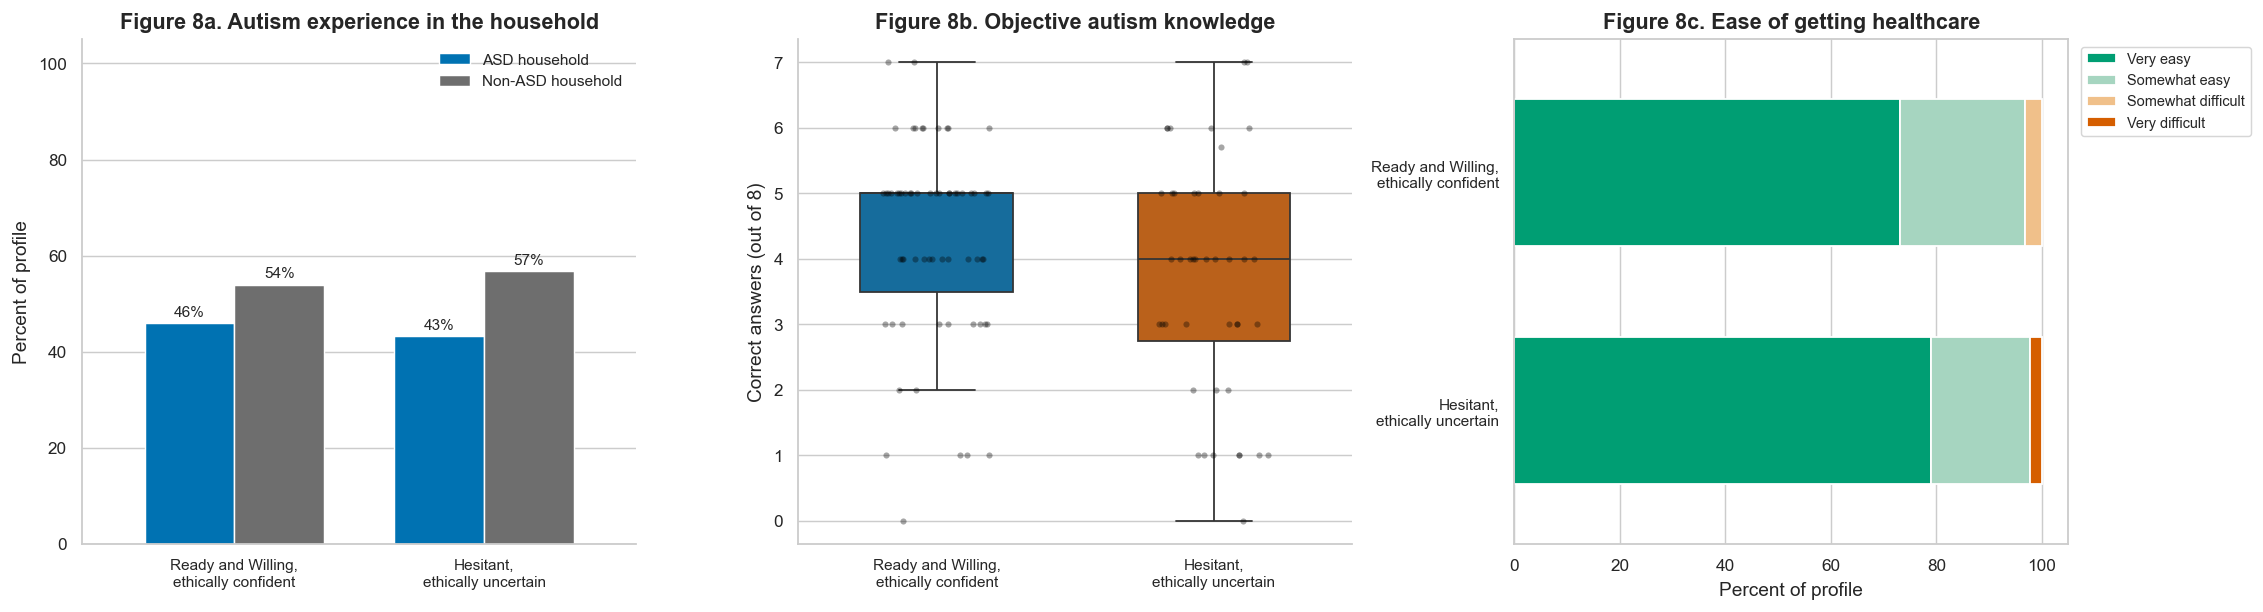

> **How to read this figure.** Three held-out context variables, none of which was used to build the clusters. (a) Autistic children are present in 43-46% of each profile (p = 0.771). (b) Objective autism knowledge, 8-item score (p = 0.063). (c) Reported ease of getting healthcare (p = 0.351). All three comparisons are exploratory.

In [21]:
# --- 11.3 Figure 8: profiling plots -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17.5, 4.8))

# (a) Autism experience
asd_pct = (pd.crosstab(model_df['cluster'], model_df['asd_household'], normalize='index') * 100
           ).reindex(CLUSTER_ORDER)
asd_pct = asd_pct.reindex(columns=[c for c in ['ASD household', 'Non-ASD household'] if c in asd_pct.columns])
asd_pct.plot(kind='bar', ax=axes[0], color=[OKABE_ITO[0], GREY], edgecolor='white', width=0.72, rot=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f%%', fontsize=8.5, padding=2)
axes[0].set_ylabel('Percent of profile')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 105)
axes[0].set_title('Figure 8a. Autism experience in the household')
axes[0].set_xticklabels([t.get_text().replace(', ', ',\n') for t in axes[0].get_xticklabels()], fontsize=8.5)
axes[0].legend(frameon=False, fontsize=8.5, title='')

# (b) Autism knowledge
knowledge_plot = model_df[['cluster', 'autism_knowledge_score']].dropna()
sns.boxplot(data=knowledge_plot, x='cluster', y='autism_knowledge_score', order=CLUSTER_ORDER,
            hue='cluster', hue_order=CLUSTER_ORDER, palette=COLORS, legend=False,
            width=0.55, fliersize=0, ax=axes[1])
sns.stripplot(data=knowledge_plot, x='cluster', y='autism_knowledge_score', order=CLUSTER_ORDER,
              color='black', alpha=0.35, size=3.4, jitter=0.2, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Correct answers (out of 8)')
axes[1].set_title('Figure 8b. Objective autism knowledge')
axes[1].set_xticks(range(len(CLUSTER_ORDER)))
axes[1].set_xticklabels([c.replace(', ', ',\n') for c in CLUSTER_ORDER], fontsize=8.5)

# (c) Healthcare access
access_order = ['Very easy', 'Somewhat easy', 'Somewhat difficult', 'Very difficult']
access_pct = (pd.crosstab(model_df['cluster'], model_df['healthcare_access'], normalize='index') * 100
              ).reindex(CLUSTER_ORDER)
access_pct = access_pct.reindex(columns=[c for c in access_order if c in access_pct.columns])
access_pct.plot(kind='barh', stacked=True, ax=axes[2],
                color=[OKABE_ITO[2], '#A6D5C0', '#F0C08A', OKABE_ITO[1]][:access_pct.shape[1]],
                edgecolor='white', linewidth=1.0, width=0.62)
axes[2].set_xlabel('Percent of profile')
axes[2].set_ylabel('')
axes[2].set_title('Figure 8c. Ease of getting healthcare')
axes[2].set_yticklabels([t.get_text().replace(', ', ',\n') for t in axes[2].get_yticklabels()], fontsize=8.5)
axes[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='')
axes[2].grid(axis='y', visible=False)
axes[2].invert_yaxis()

for ax in axes[:2]:
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.grid(axis='x', visible=False)
plt.tight_layout()
save_figure(fig, 'figure_08_profiling_context')
plt.show()

def p_for(name_startswith: str) -> str:
    hit = comparisons.loc[comparisons['variable'].str.startswith(name_startswith), 'p']
    return f'p = {hit.iat[0]:.3f}' if len(hit) else 'not tested'


asd_low, asd_high = asd_pct['ASD household'].min(), asd_pct['ASD household'].max()
caption(
    'Three held-out context variables, none of which was used to build the clusters. '
    f'(a) Autistic children are present in {asd_low:.0f}-{asd_high:.0f}% of each profile '
    f'({p_for("ASD household")}). '
    f'(b) Objective autism knowledge, 8-item score ({p_for("Autism knowledge score")}). '
    f'(c) Reported ease of getting healthcare ({p_for("Ease of healthcare access")}). '
    'All three comparisons are exploratory.'
)

---
# Key Findings and Interpretation

In [22]:
# --- 12.1 Findings, written from the computed results so the narrative cannot drift -------------
spread = (heat.max() - heat.min()).sort_values(ascending=False)
top_profile, low_profile = CLUSTER_ORDER[0], CLUSTER_ORDER[-1]

headline = pd.DataFrame({
    'profile': CLUSTER_ORDER,
    'n': [int((model_df['cluster'] == c).sum()) for c in CLUSTER_ORDER],
    '% of sample': [(model_df['cluster'] == c).mean() * 100 for c in CLUSTER_ORDER],
    'screen now or earlier (%)': [timing_pct.loc[c].get('Screen now or earlier', 0) for c in CLUSTER_ORDER],
    'wait (%)': [timing_pct.loc[c].get('Wait', 0) for c in CLUSTER_ORDER],
    'decline (%)': [timing_pct.loc[c].get('Decline', 0) for c in CLUSTER_ORDER],
    'ASD household (%)': [asd_pct.loc[c].get('ASD household', np.nan) for c in CLUSTER_ORDER],
    'autism knowledge (0-8)': [model_df.loc[model_df['cluster'].eq(c), 'autism_knowledge_score'].mean()
                               for c in CLUSTER_ORDER],
    'self-rated knowledge (1-5)': [model_df.loc[model_df['cluster'].eq(c), 'self_rated_knowledge'].mean()
                                   for c in CLUSTER_ORDER],
})
display(Markdown('### Headline summary'))
display(headline.round(1))
headline.round(2).to_csv(OUT_DIR / 'table_06_headline_summary.csv', index=False)

ward_reading = ('recovers essentially the same grouping' if ari_ward > 0.75 else
                'recovers a substantially similar grouping' if ari_ward > 0.50 else
                'finds a noticeably different split')
sil_final = validation.set_index('K').loc[K_FINAL, 'silhouette']
sil_sentence = ('The groups are reasonably well separated for attitude data.' if sil_final >= 0.25 else
                'The groups are only weakly separated; caregivers lie on a continuum rather than in distinct islands.')

notable_context = comparisons[comparisons['p'] < 0.05]
context_sentence = (
    'None of the held-out context variables separates the profiles at the conventional 5% level.'
    if notable_context.empty else
    'Context variable(s) separating the profiles at the conventional 5% level: '
    + '; '.join(f"**{r['variable']}** ({r['effect measure']} = {r['effect size']:.2f}, "
                f"p = {r['p']:.3f}, n = {int(r['n'])})" for _, r in notable_context.iterrows())
    + '. Everything else does not.')

asd_low_pct, asd_high_pct = asd_pct['ASD household'].min(), asd_pct['ASD household'].max()
know_row = comparisons[comparisons['variable'].str.startswith('Autism knowledge score')]
access_row = comparisons[comparisons['variable'].eq('Ease of healthcare access')]
know_p_txt = f"p = {know_row['p'].iat[0]:.3f}" if len(know_row) else 'not tested'
access_p_txt = f"p = {access_row['p'].iat[0]:.3f}" if len(access_row) else 'not tested'

now_high = timing_pct.loc[top_profile].get('Screen now or earlier', 0)
now_low = timing_pct.loc[low_profile].get('Screen now or earlier', 0)
wait_low = timing_pct.loc[low_profile].get('Wait', 0)
decline_low = timing_pct.loc[low_profile].get('Decline', 0)

accuracy_mean = {c: model_df.loc[model_df['cluster'].eq(c), 'tfa_screen_accuracy'].mean() for c in CLUSTER_ORDER}
believe_mean = {c: model_df.loc[model_df['cluster'].eq(c), 'tfa_believe_positive'].mean() for c in CLUSTER_ORDER}

spread_table = '\n'.join(f'| {i + 1} | {d} | {v:.2f} |' for i, (d, v) in enumerate(spread.items()))
sizes_text = ' and '.join(str(int(v)) for v in headline['n'])

display(Markdown(f'''
## 1. How many profiles, and why

The final solution has **{K_FINAL} caregiver profiles** covering **{N} caregivers** — {len(step1)} records in the cleaned file,
less {len(step1) - len(eligible)} who did not complete the attitude instrument and {len(eligible) - N} who skipped at least one
item used in the final features.

$K = {K_FINAL}$ was selected because it had the **highest average silhouette ({sil_final:.2f})**, because every group is large
enough to describe and act on ({sizes_text} caregivers), and because the resulting profiles are plainly interpretable. Where the
criteria disagreed, the smaller and simpler solution was preferred — a rule fixed in §7 before the numbers were seen.
{sil_sentence}

**Two robustness checks, reported as they came out.** Ward hierarchical clustering — a different algorithm with different
geometric assumptions — {ward_reading} (adjusted Rand index = {ari_ward:.2f}). Removing the willingness item and re-clustering
on the remaining {len(FEATURE_NAMES) - 1} domains gives an adjusted Rand index of {ari_no_will:.2f}.
{'Both checks support the solution.' if min(ari_ward, ari_no_will) > 0.5 else
 'The Ward disagreement is a real caveat and is carried into the limitations: where attitudes form a gradient rather than '
 'separated groups, exactly where the dividing line falls is partly a property of the algorithm. Treat these profiles as one '
 'reasonable summary of a continuum of support, not as two naturally occurring caregiver types.'}

## 2. What the profiles look like

The profiles differ **in the same direction on every attitude domain**. *{top_profile}* sits above the sample average on all
{len(FEATURE_NAMES)} domains; *{low_profile}* sits below on all of them. There is no profile that is, say, ethically
enthusiastic but practically constrained, or comfortable with the idea but doubtful about the procedures.

That pattern is itself a finding: **in this sample, attitudes toward infant autism screening behave as one broad dimension of
support rather than as several independent concerns.** The domains stay conceptually distinct — §6.6 shows none is redundant
with another — but they move together within the same people. A caregiver with ethical reservations also tends to feel less at
ease, to find the logistics harder, and to be more selective about procedures.

Full plain-language descriptions are in §9.5, generated from the profile table so they always match the fitted solution.

## 3. Which domains separate the profiles most

| Rank | Domain | Spread between profiles (SD) |
| --- | --- | --- |
{spread_table}

**{spread.index[0]}** separates the profiles most ({spread.iloc[0]:.2f} SD); **{spread.index[-1]}** separates them least
({spread.iloc[-1]:.2f} SD). Domains near the bottom of that table are common ground — messages about them will land much the
same way with every caregiver. Domains near the top are where a communication strategy has leverage.

*Ethical & moral acceptability* and *Emotional comfort* travel together. Whether a caregiver believes infant screening is
**the right thing to do** is inseparable in these data from whether the prospect makes them **feel at ease**. Reassurance about
procedures will not resolve an ethical reservation, and an ethical argument will not resolve discomfort.

## 4. Willingness to screen now, later, or not at all

`tfa_test_today` was deliberately **excluded from the clustering** (§5, Rule 3), so this is a genuine external check rather than
a restatement of the inputs. The profiles differ sharply
({timing_stats['test']}: p = {timing_stats['p']:.4f}, Cramer's V = {timing_v:.2f}):

- **{now_high:.0f}%** of *{top_profile}* would screen now or earlier, against **{now_low:.0f}%** of *{low_profile}*.
- **{wait_low:.0f}%** of *{low_profile}* would **wait** — but only **{decline_low:.0f}%** would **decline outright**.

**That second contrast is the most operationally useful result in the analysis.** Even in the less supportive profile, outright
refusal is rare: hesitance is overwhelmingly expressed as *deferral*, not rejection. "Wait" and "decline" are different
caregivers who need different responses. A caregiver who would wait has accepted the premise and is negotiating timing — an
information and scheduling problem. A caregiver who would decline is rejecting the premise — an ethics and trust problem. A
single yes/no uptake statistic collapses the one distinction a programme could actually act on.

§10.2 adds a related detail. *{low_profile}* caregivers demand **stricter** accuracy before they would use the test
(mean {accuracy_mean[low_profile]:.2f} vs {accuracy_mean[top_profile]:.2f}, where 1 = "98-100% accurate") and say they would
believe a positive result **less** (mean {believe_mean[low_profile]:.2f} vs {believe_mean[top_profile]:.2f}). Hesitance is tied
to confidence in the test, not only to feelings about screening.

## 5. Who is in each profile

{context_sentence}

**The important result in this section is largely a negative one.** Autistic children are present in
{asd_low_pct:.0f}%-{asd_high_pct:.0f}% of each profile. Objective autism knowledge ({know_p_txt}), healthcare access
({access_p_txt}), self-rated knowledge, education, income, area, gender, prematurity and child special needs do not
meaningfully distinguish the profiles either.

**The attitude profiles cut across demographic and experiential lines rather than mapping onto them.** The practical
implication is direct: **a caregiver's stance cannot be predicted from their background.** There is no demographic proxy — not
income, not education, not already having an autistic child — that reliably identifies who will hesitate. Any plan that tailors
screening conversations by demographic segment will misroute a large share of families. The attitudes have to be asked about,
not inferred.

On **"HD versus non-HD household"**: no variable of that name or definition exists in this dataset. The closest
clearly-defined analogue, and the one the study's own analysis plan uses, is ASD versus non-ASD household — reported above and
in Figure 8a.
'''))

### Headline summary

,profile,n,% of sample,screen now or earlier (%),wait (%),decline (%),ASD household (%),autism knowledge (0-8),self-rated knowledge (1-5)
0,"Ready and Willing, ethically confident",63,58.90,84.10,15.90,0.00,46.00,4.30,3.50
1,"Hesitant, ethically uncertain",44,41.10,34.10,59.10,6.80,43.20,3.70,3.40



## 1. How many profiles, and why

The final solution has **2 caregiver profiles** covering **107 caregivers** — 135 records in the cleaned file,
less 4 who did not complete the attitude instrument and 24 who skipped at least one
item used in the final features.

$K = 2$ was selected because it had the **highest average silhouette (0.24)**, because every group is large
enough to describe and act on (63 and 44 caregivers), and because the resulting profiles are plainly interpretable. Where the
criteria disagreed, the smaller and simpler solution was preferred — a rule fixed in §7 before the numbers were seen.
The groups are only weakly separated; caregivers lie on a continuum rather than in distinct islands.

**Two robustness checks, reported as they came out.** Ward hierarchical clustering — a different algorithm with different
geometric assumptions — finds a noticeably different split (adjusted Rand index = 0.21). Removing the willingness item and re-clustering
on the remaining 5 domains gives an adjusted Rand index of 0.49.
The Ward disagreement is a real caveat and is carried into the limitations: where attitudes form a gradient rather than separated groups, exactly where the dividing line falls is partly a property of the algorithm. Treat these profiles as one reasonable summary of a continuum of support, not as two naturally occurring caregiver types.

## 2. What the profiles look like

The profiles differ **in the same direction on every attitude domain**. *Ready and Willing, ethically confident* sits above the sample average on all
6 domains; *Hesitant, ethically uncertain* sits below on all of them. There is no profile that is, say, ethically
enthusiastic but practically constrained, or comfortable with the idea but doubtful about the procedures.

That pattern is itself a finding: **in this sample, attitudes toward infant autism screening behave as one broad dimension of
support rather than as several independent concerns.** The domains stay conceptually distinct — §6.6 shows none is redundant
with another — but they move together within the same people. A caregiver with ethical reservations also tends to feel less at
ease, to find the logistics harder, and to be more selective about procedures.

Full plain-language descriptions are in §9.5, generated from the profile table so they always match the fitted solution.

## 3. Which domains separate the profiles most

| Rank | Domain | Spread between profiles (SD) |
| --- | --- | --- |
| 1 | Willingness to screen | 1.25 |
| 2 | Ethical & moral acceptability | 1.09 |
| 3 | Procedure acceptability | 0.65 |
| 4 | Practical feasibility | 0.64 |
| 5 | Result trust & low regret | 0.59 |
| 6 | Emotional comfort (vs concern) | 0.52 |

**Willingness to screen** separates the profiles most (1.25 SD); **Emotional comfort (vs concern)** separates them least
(0.52 SD). Domains near the bottom of that table are common ground — messages about them will land much the
same way with every caregiver. Domains near the top are where a communication strategy has leverage.

*Ethical & moral acceptability* and *Emotional comfort* travel together. Whether a caregiver believes infant screening is
**the right thing to do** is inseparable in these data from whether the prospect makes them **feel at ease**. Reassurance about
procedures will not resolve an ethical reservation, and an ethical argument will not resolve discomfort.

## 4. Willingness to screen now, later, or not at all

`tfa_test_today` was deliberately **excluded from the clustering** (§5, Rule 3), so this is a genuine external check rather than
a restatement of the inputs. The profiles differ sharply
(chi-square (small expected cells - treat p with caution): p = 0.0000, Cramer's V = 0.52):

- **84%** of *Ready and Willing, ethically confident* would screen now or earlier, against **34%** of *Hesitant, ethically uncertain*.
- **59%** of *Hesitant, ethically uncertain* would **wait** — but only **7%** would **decline outright**.

**That second contrast is the most operationally useful result in the analysis.** Even in the less supportive profile, outright
refusal is rare: hesitance is overwhelmingly expressed as *deferral*, not rejection. "Wait" and "decline" are different
caregivers who need different responses. A caregiver who would wait has accepted the premise and is negotiating timing — an
information and scheduling problem. A caregiver who would decline is rejecting the premise — an ethics and trust problem. A
single yes/no uptake statistic collapses the one distinction a programme could actually act on.

§10.2 adds a related detail. *Hesitant, ethically uncertain* caregivers demand **stricter** accuracy before they would use the test
(mean 2.23 vs 2.70, where 1 = "98-100% accurate") and say they would
believe a positive result **less** (mean 3.27 vs 2.40). Hesitance is tied
to confidence in the test, not only to feelings about screening.

## 5. Who is in each profile

Context variable(s) separating the profiles at the conventional 5% level: **Wishes an earlier diagnosis (ASD households)** (Cramer's V = 0.48, p = 0.004, n = 48); **Any premature birth** (Cramer's V = 0.23, p = 0.017, n = 107). Everything else does not.

**The important result in this section is largely a negative one.** Autistic children are present in
43%-46% of each profile. Objective autism knowledge (p = 0.063), healthcare access
(p = 0.351), self-rated knowledge, education, income, area, gender, prematurity and child special needs do not
meaningfully distinguish the profiles either.

**The attitude profiles cut across demographic and experiential lines rather than mapping onto them.** The practical
implication is direct: **a caregiver's stance cannot be predicted from their background.** There is no demographic proxy — not
income, not education, not already having an autistic child — that reliably identifies who will hesitate. Any plan that tailors
screening conversations by demographic segment will misroute a large share of families. The attitudes have to be asked about,
not inferred.

On **"HD versus non-HD household"**: no variable of that name or definition exists in this dataset. The closest
clearly-defined analogue, and the one the study's own analysis plan uses, is ASD versus non-ASD household — reported above and
in Figure 8a.


## 6. Implications for implementation

**Communication.** Because support is one broad dimension rather than several independent concerns, a single reassurance —
"it's quick", "it's accurate" — will not move a hesitant caregiver whose reservation is ethical. Conversations need to open with
what the caregiver's actual concern is rather than assuming it is logistical.

**Informed consent.** The profiles differ on whether a result would be *believed* and whether testing would be *regretted*.
Consent conversations should therefore cover what a positive result does and does not establish at 4 months, what a negative
result does not rule out, and what happens next in each case. The two scenarios need equal airtime; caregivers were asked about
both, and their appraisals of them differ.

**Test accuracy communication.** The evidentiary-standard items (§6.4, §10.2) turned out **not** to form a single trait —
how accurate a test must be, how certain it must be about support needs, and how useful an autism-status-only result is are
*separate judgements*. A caregiver may accept an imperfect test but reject one that cannot say how much help their child will
need. These have to be addressed as distinct questions, not bundled into one "the test is X% accurate" statement.

**Procedure choice.** Procedure acceptability is a distinct domain and one where the programme has direct control. Modality
choice is a lever available to implementers in a way that caregiver ethics is not.

**Equitable access.** Because attitudes do not track demographics, equitable implementation is about *access to the
conversation*, not about targeting particular communities. Perceived logistical burden is a separate and addressable barrier
from attitudinal hesitance, and conflating the two would mean offering scheduling help to someone with an ethical objection.

**Family support.** The "would wait" group is the natural focus for follow-up: they are open to screening but not yet ready.
Deferral is a decision that can be revisited, which a decline usually is not.

## 7. Limitations

- **Self-selected, non-representative sample.** Caregivers who complete a long survey about autism screening are not a random
  sample of caregivers. The absolute percentages here should not be read as population estimates; comparisons between profiles
  rest on firmer ground than the levels do.
- **Cross-sectional.** Everything was measured at one moment. No attitude can be shown to precede, let alone cause, another.
- **Hypothetical scenario.** Respondents were asked what they *would* do about a test that does not currently exist. Stated
  intent systematically overstates real uptake, and the gap is usually largest among those who say yes.
- **Modest sample size.** With roughly 130 caregivers, small differences cannot be detected reliably, and cluster solutions
  beyond two or three groups are not well supported.
- **Response and social-desirability bias.** Screening one's own baby for a developmental condition is a socially loaded
  question, and answers may lean toward what feels like the responsible reply.
- **Sensitivity to the algorithm.** K-means and Ward linkage do not place the same caregivers together (§8.1). Where responses
  form a continuum, the position of the dividing line is partly an artefact of the method. The profiles describe the ends of a
  gradient; they do not identify a natural boundary.
- **Sensitivity to feature selection.** Clusters depend on which variables go in. Different defensible domain definitions would
  produce somewhat different groups. Every choice made here — item screening thresholds, reverse-coding, domain composition,
  the alpha rule — is documented in §4 to §6 so it can be challenged and re-run.
- **Two domains have only modest internal consistency**, and are flagged as rough indices in §6.3 rather than precise scales.
- **Slider anchor text is missing from the export.** Direction for the unanchored sliders was declared and then verified
  empirically (§6.3), but not against the REDCap data dictionary. This affects the wording of interpretations, not the
  clustering itself.
- **Exploratory comparisons, uncorrected.** §11 tests many context variables without multiplicity adjustment. Roughly one in
  twenty would reach p < .05 by chance. Effect sizes, not p-values, should drive interpretation.
- **Labels are shorthand.** Cluster names were generated from the profile pattern to be descriptive and non-stigmatising. They
  are not validated constructs and carry no clinical meaning.

## 8. Statement of scope

**These clusters describe patterns of response within this sample. They are not fixed clinical categories.** They are not
diagnostic, not predictive of individual behaviour, not stable over time, and not validated against any external criterion. They
should be used to structure thinking about the *range* of caregiver perspectives a screening programme will encounter — and for
nothing else. No caregiver should be assigned to a profile, or treated differently on the basis of one, in any clinical or
programmatic setting.

In [23]:
# --- 12.2 Save the final analytic dataset and summary tables ------------------------------------
export_columns = (
    ['record_id', 'cluster', 'cluster_id']
    + FEATURE_NAMES
    + RETAINED_FIELDS
    + ['timing_decision', 'tfa_test_today', 'tfa_test_choice', 'tfa_screen_accuracy', 'tfa_future',
       'tfa_overall_help']
    + ['asd_household', 'fif_num_autistic', 'parent_autistic', 'works_with_autistic', 'child_special_needs',
       'any_premature', 'wish_earlier_diagnosis', 'autism_knowledge_score', 'self_rated_knowledge',
       'healthcare_access', 'education', 'household_income', 'area', 'gender', 'fif_num_children',
       'demo_num_home']
)
export = model_df.copy()
for feature in FEATURE_NAMES:
    export[feature] = features[feature].to_numpy()
export = export[[c for c in dict.fromkeys(export_columns) if c in export.columns]]

# No free text, no dates, no contact fields - record_id is a study-internal sequence number only.
assert not any(c in export.columns for c in
               ['occup', 'contact_results', 'zip_demo', 'age_check_demo', 'demo_date_gift_sent']), \
    'Potentially identifying column in the export.'

analytic_path = OUT_DIR / 'caregiver_cluster_analytic_dataset.csv'
export.to_csv(analytic_path, index=False)

written = sorted(p.name for p in OUT_DIR.glob('*.csv')) + sorted(p.name for p in OUT_DIR.glob('*.png'))
display(Markdown('### Files written'))
display(pd.DataFrame({'file': written}))

import sys, sklearn, scipy, matplotlib
display(Markdown('### Environment (for reproducibility)'))
display(pd.DataFrame({
    'component': ['Python', 'pandas', 'numpy', 'scikit-learn', 'scipy', 'matplotlib', 'seaborn', 'RANDOM_STATE'],
    'version': [sys.version.split()[0], pd.__version__, np.__version__, sklearn.__version__,
                scipy.__version__, matplotlib.__version__, sns.__version__, str(RANDOM_STATE)],
}))
print(f'Analytic dataset with cluster assignments: {analytic_path}')
print(f'Rows: {len(export)}   Columns: {export.shape[1]}')

### Files written

,file
0,caregiver_cluster_analytic_dataset.csv
1,table_01_data_dictionary.csv
2,table_02_reverse_coding_log.csv
3,table_03_cluster_validation_metrics.csv
4,table_04_cluster_profiles.csv
5,table_05_post_cluster_comparisons.csv
6,table_06_headline_summary.csv
7,figure_01_correlation_heatmap.png
8,figure_02_elbow_and_silhouette.png
9,figure_03_ward_robustness.png


### Environment (for reproducibility)

,component,version
0,Python,3.9.6
1,pandas,2.2.3
2,numpy,2.0.2
3,scikit-learn,1.6.1
4,scipy,1.13.1
5,matplotlib,3.9.4
6,seaborn,0.13.2
7,RANDOM_STATE,42


Analytic dataset with cluster assignments: /Users/namomac/esd-redcap-metadata-watcher/Caregiver Project/Caregiver Outputs/caregiver_cluster_analytic_dataset.csv
Rows: 107   Columns: 59
